# Preprocesamiento

<div style="text-align: justify;">

El presente _notebook_ tiene proposito documentar el desarrollo de la etapa de pre-procesamiento de los datos de expresión génica seleccionados del repositorio [BARRA:CuRDa](https://sbcb.inf.ufrgs.br/barracurda) que se detallan en la Tabla 1:
 
|    Categoría    |  Dataset   | Código (GSE) | Tipo de cáncer |            Especie            | Tumor/Met/Normal |                              Enlace fuente                              |
|-----------------|------------|--------------|----------------|-------------------------------|------------------|-------------------------------------------------------------------------|
| Parametrización | Dataset A1 |   GSE69240   |     Mama       | *Homo sapiens* (Tax ID: 9606) |     25/00/10     | [NCBI GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE69240) |
| Parametrización | Dataset A2 |   GSE40419   |     Pulmón     | *Homo sapiens* (Tax ID: 9606) |     87/00/77     | [NCBI GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE40419) |
| Experimentación | Dataset B1 |   GSE60052   |     Pulmón     | *Homo sapiens* (Tax ID: 9606) |     79/00/07     | [NCBI GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE60052) |
| Experimentación | Dataset B2 |   GSE50760   |     Colon      | *Homo sapiens* (Tax ID: 9606) |     18/18/18     | [NCBI GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE50760) | 
| Experimentación | Dataset B3 |   GSE52194   |     Mama       | *Homo sapiens* (Tax ID: 9606) |     17/00/03     | [NCBI GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE52194) |

El flujo de procesamiento de estos datos sigue la siguiente secuencia de pasos:

1. **Exploración de _datasets_:** Se realiza la carga y exploración de los datos mediante estadística descriptiva, con el objetivo de construir una base de conocimiento que permita identificar la naturaleza de los datos y sustentar las decisiones metodológicas posteriores.
2. **Selección de características:** Se aplica la reducción de genes de los _datasets_ mediante técnicas de _feature selection_ estándar en la literatura: _near-zero variance_, _fold-change_ y _Principal Component Analysis_ (PCA), presentando los gráficos de los resultados junto con su respectivo sustento teórico. 
3. **Reconocimiento de identificadores de genes:** Mediante el uso de las funciones propias, se transforman los identificadores _ENSG_ a _EntrezID_, obteniendo además sus respectivos _Gene Symbols_. Asimismo, se filtran aquellos identificadores marcados como obsoletos (_deprecated_) según [Ensembl](https://jun2026.archive.ensembl.org/index.html) y se realiza tratamiento de datos duplicados.
4. **Creación de matrices de distancia:** Se calcula la correlación de Spearman utilizando los _datasets_ reducidos obtenidos en el paso anterior. Paralelamente, mediante la función `compute_gene_similarity_matrix_by_batch` del paquete `biocluster`, se calcula el índice de Wang para cada par de genes, obteniendo la matriz correspondiente y verificando que sus valores representen una medida de distancia (y no de similitud).

</div>

## Exploración de _datasets_

<div style="text-align: justify;">

Dentro de esta sección se explora la naturaleza de los datos (principalmente muestras) mediante tres pasos fundamentales: **Diagnóstico, Relación media-varianza y Pruebas de distribución de normalidad**, con la finalidad de verificar que los datos estén en condiciones adecuadas para el siguiente paso. En la Tabla 2 se detallan las actividades que componen esta etapa.

**Tabla 1.** Descripción de _datasets_ de estudio.
|           Paso          | Descripción |
|-------------------------|-------------|
|       Diagnóstico       | Se aplica el estudio generalizado de los _datasets_, verificando la cantidad de genes, muestras, datos nulos, datos enteros, promedio del coeficiente de variación entre muestras y escala de los datos [1]. Todo lo anterior resulta en una tabla resumen de estas estadísticas. |
| Relación media-varianza | Se realiza el gráfico _mean vs variance plot_ con la finalidad de verificar si el curado realizado en BARRA:CuRDa ha estabilizado efectivamente la varianza, evitando que datos ruidosos sesguen los análisis posteriores debido al efecto que puede tener la transformación $log()$ al exagerar los cambios de expresión en el _fold-change_ [1] [2]. |
|  Pruebas de normalidad  | Se realizan el gráfico y las pruebas de normalidad en cada muestra, con el fin de justificar el uso de _PCA_ a posteriori [1]. |

_**Nota de autor**_: Tomando en consideración las fuentes [1], [2] y [3], esta exploración resulta completamente relevante para comprender la condición de los datos antes de aplicar las pruebas a posteriori, particularmente para evitar errores al momento de aplicar debidamente el _PCA_ y el _fold-change_, dado que existen muchas condiciones que pueden sesgar los datos:
   * Si la escala de los conteos está en escala natural o entera, estamos presenciando asimetría en los datos que sesga los análisis hacia los genes de mayor expresión en términos de magnitud.
   * Si la relación media-varianza no presenta homocedasticidad o estabilidad, estamos ante datos que sesgan el _fold-change_ hacia genes que se expresan poco y varían mucho, lo cual puede conducir al estudio de variables irrelevantes. Asimismo, implica la presencia de heterocedasticidad, que sesga el uso de _PCA_ y requeriría revisión a posteriori.
   * Si las muestras no presentan un comportamiento cercano a la distribución normal o binomial, entonces el método de correlación a utilizar varía entre el de Spearman y el de Pearson.

</div>

[1] Holmes, S., & Huber, W. (2019). Modern Statistics for Modern Biology. Cambridge University Press.
[2] Love, M.I., Huber, W. & Anders, S. Moderated estimation of fold change and dispersion for RNA-seq data with DESeq2. Genome Biol 15, 550 (2014). https://doi.org/10.1186/s13059-014-0550-8
[3] Kumari, S., Nie, J., Chen, H. S., Ma, H., Stewart, R., Li, X., Lu, M. Z., Taylor, W. M., & Wei, H. (2012). Evaluation of gene association methods for coexpression network construction and biological knowledge discovery. PloS one, 7(11), e50411. https://doi.org/10.1371/journal.pone.0050411


In [1]:
############################
# Importaciones
############################
import os                                                   # Llamadas al SO.
from pathlib import Path                                    # Estructura para directorios.
import pandas as pd                                         # Manejo de dataframes.
import numpy as np                                          # Manejo de datos numericos.
import matplotlib.pyplot as plt                             # Gráficos.
from scipy import stats                                     # Pruebas estadísticas generales.
from IPython.display import display                         # Interfaz para mostrar resultados.

############################
# Constantes
############################
DATA_DIR          = Path(os.getcwd()).resolve().parent / "Datasets" / "Gene_Expression_source"
OUTPUT_DIR_PREFIX = DATA_DIR / "Results"

############################
# Funciones secundarias
############################

def processing_exploration(name: str, df: pd.DataFrame):
    """
    Función que encapsula el procesamiento del paso de exploración de
    datasets obteniendo las estadísticas descriptivas de los dataframes
    en estudio.

    Notas de ayuda:
        - Las listas por comprensión tienen el formato [<elemento> <ciclo for> <condiciones>]
        - El join une elementos considerando el caracter string proporcionado como separador.
        - floor considera el MENOR valor entero.
        - La comprobación de tipos son dos condiciones aproximadas:
            I.  El valor de Transcripts Per Million (TPM) al aplicarse una operación de logaritmo no supera en promedio
                el valor de ~20 a ~25.
            II. La transformación rara vez daría decimales.
        - La suma de valores NaN es por columnas y posteriormente es por columna.}
        - CV es el coeficiente de variación.
        - axis = 0 -> El calculo es a nivel de columnas.
    """
    
    # Fragmentación del dataframe.
    cols_meta = ['ID', 'class']
    cols_gene = [c for c in df.columns if c not in cols_meta]
    df_genes  = df[cols_gene]

    # Balance de muestras.
    conteos = df['class'].value_counts()
    balance = ' | '.join(f"{cls}: {n}" for cls, n in conteos.items())

    # Verificación de escala de valores logaritmica.
    media_global = df_genes.values.mean()
    maximo       = df_genes.values.max()
    pct_enteros  = np.mean(df_genes.values == np.floor(df_genes.values))
    tipo = 'log₂()' if (media_global < 20 and pct_enteros < 0.5) else 'REVISAR'

    # Estadísticas de interés.
    n_genes    = len(cols_gene)
    n_samples  = df.shape[0]
    n_nulls    = int(df_genes.isna().sum().sum())
    pct_nulls  = 100 * n_nulls / df_genes.size
    gene_mean  = df_genes.mean(axis=0)
    gene_std   = df_genes.std(axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        cv = gene_std / gene_mean.replace(0, np.nan)
    mean_cv = cv.replace([np.inf, -np.inf], np.nan).mean()

    # Resultado de retorno.
    return {
        "Dataset":        name,
        "N° genes":       n_genes,
        "N° muestras":    n_samples,
        "Balance clases": balance,
        "Escala":         tipo,
        "Media global":   round(float(media_global), 3),
        "Máximo":         round(float(maximo), 3),
        "N° nulos":       n_nulls,
        "% nulos":        round(pct_nulls, 3),
        "CV promedio":    round(float(mean_cv), 3),
    }

def processing_mean_variance(name: str, df: pd.DataFrame, ax, alpha: float = 0.05) -> dict:
    """
    Función que encapsula el procesamiento del paso de relación
    media-varianza (mean vs variance plot), además de contabilizar
    los GENES que siguen o no una distribución normal (Shapiro-Wilk)
    a través de las muestras.
    """

    # Fragmentación del dataframe.
    cols_meta = ['ID', 'class']
    cols_gene = [c for c in df.columns if c not in cols_meta]
    df_genes  = df[cols_gene]

    # Media y varianza por gen (a través de las muestras).
    gene_mean = df_genes.mean(axis=0)
    gene_var  = df_genes.var(axis=0)

    # Plot: Gráfico de nube de puntos que aplica el uso de
    # un tamaño pequeño por cada uno (s=5) y una baja opacidad
    # (alpha=0.3) para tener en consideración la opacidad (la
    # escala del gráfico es logaritmica).
    ax.scatter(gene_mean, gene_var, s=5, alpha=0.3)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Media (log)")
    ax.set_ylabel("Varianza (log)")

    # Conteo de normalidad por GEN (columna, a través de las muestras).
    n_normal    = 0
    n_no_normal = 0
    for gen in cols_gene:
        values = df_genes[gen].dropna()
        if len(values) < 3:
            continue  # Shapiro-Wilk requiere al menos 3 observaciones.
        if len(values) > 5000:
            values = values.sample(5000, random_state=42)  # resguardo, no debería activarse (n_muestras < 100).
        _, p = stats.shapiro(values)
        if p > alpha:
            n_normal += 1
        else:
            n_no_normal += 1

    n_total = n_normal + n_no_normal
    pct_normal = 100 * n_normal / n_total if n_total else 0

    # Título y anotación con el resumen de normalidad.
    ax.set_title(f"{name}\nNormales: {n_normal} | No normales: {n_no_normal}")

    return {
        "Dataset":              name,
        "N° genes normales":    n_normal,
        "N° genes no normales": n_no_normal,
        "% genes normales":     round(pct_normal, 1),
    }


# Lectura de datasets (en formato zip).
DATASETS = {
    "A1": pd.read_csv(DATA_DIR/"GSE69240.csv.zip"), 
    "A2": pd.read_csv(DATA_DIR/"GSE40419.csv.zip"),
    "B1": pd.read_csv(DATA_DIR/"GSE60052.csv.zip"),
    "B2": pd.read_csv(DATA_DIR/"GSE50760.csv.zip"),
    "B3": pd.read_csv(DATA_DIR/"GSE52194.csv.zip")
}

,Dataset,N° genes,N° muestras,Balance clases,Escala,Media global,Máximo,N° nulos,% nulos,CV promedio
0,A1,58735,35,Tumor: 25 | Normal: 10,log₂(),3.977,23.238,0,0.0,0.137
1,A2,58735,164,Tumor: 87 | Normal: 77,log₂(),4.456,21.194,0,0.0,0.085
2,B1,58735,86,Tumor: 79 | Normal: 7,log₂(),4.652,19.348,0,0.0,0.107
3,B2,58148,54,Primary: 18 | Normal: 18 | Metastasis: 18,log₂(),3.843,22.053,0,0.0,0.090
4,B3,58735,20,Tumor: 17 | Normal: 3,log₂(),3.467,21.235,0,0.0,0.185


C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\benja\AppData\Roaming\Python\Python313\site-pac

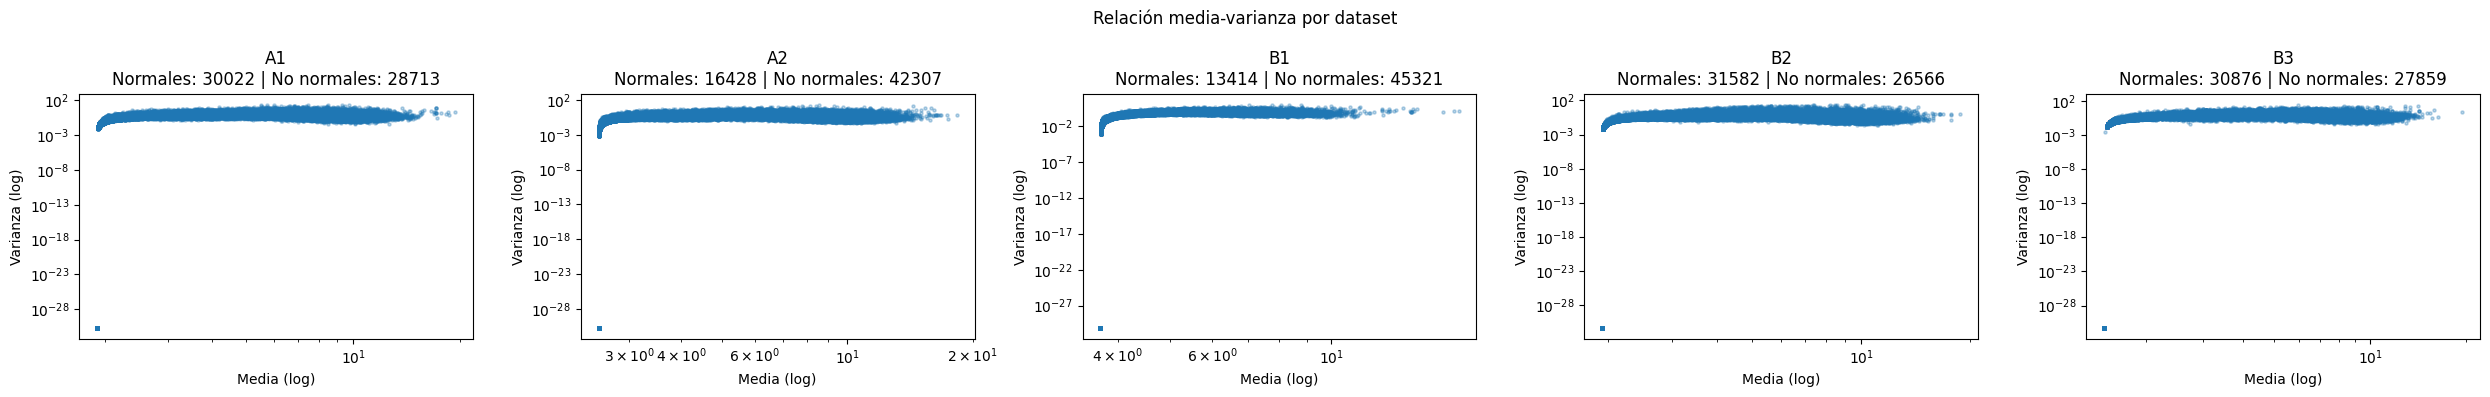

,Dataset,N° genes normales,N° genes no normales,% genes normales
0,A1,30022,28713,51.1
1,A2,16428,42307,28.0
2,B1,13414,45321,22.8
3,B2,31582,26566,54.3
4,B3,30876,27859,52.6


<timed exec>:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


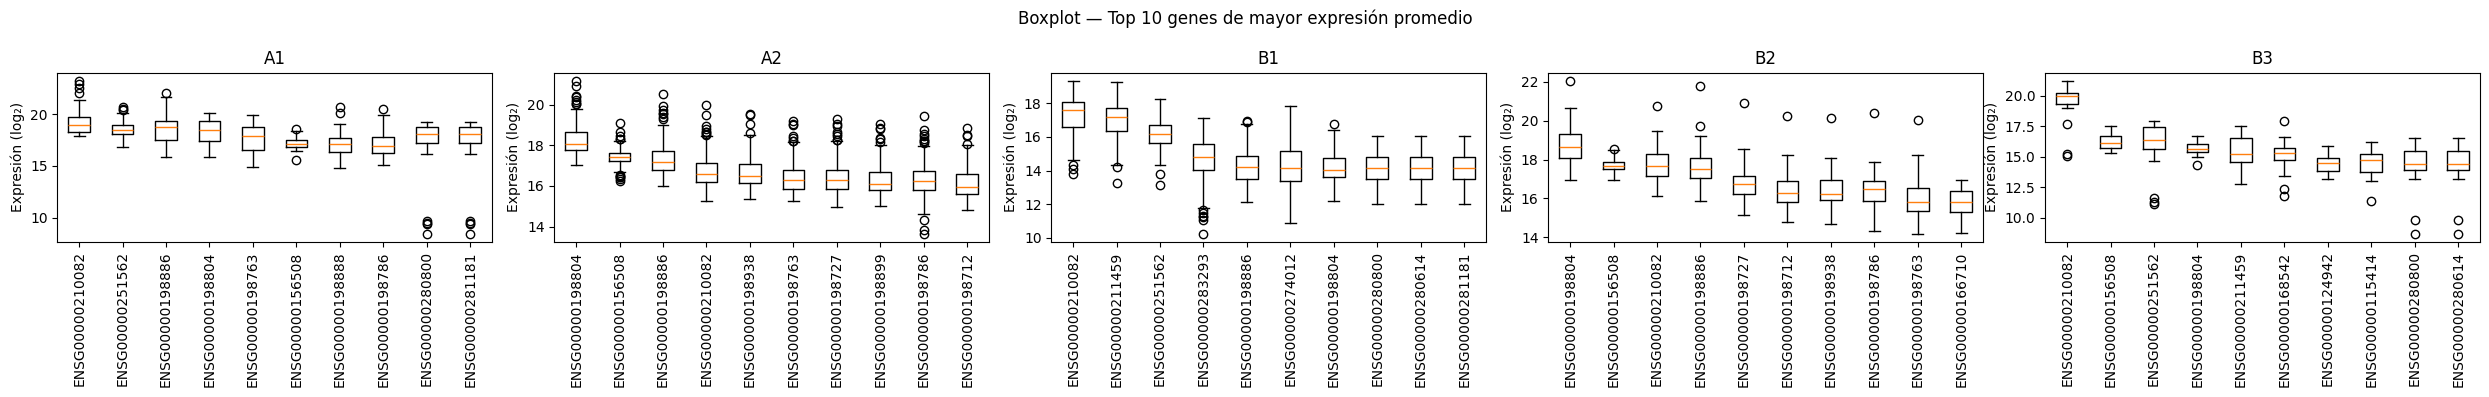

CPU times: total: 57.5 s
Wall time: 57.7 s


In [2]:
%%time
##############################
# EJECUCIÓN DE PASOS
##############################

# Paso 1 - Exploración.
summary_rows = [processing_exploration(name, df) for name, df in DATASETS.items()]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Paso 2 y 3 - Relación media-varianza y procesamiento de normalidad.
n = len(DATASETS)

# Mosaico: Una grilla de 1 fila y 5 columnas de ancho variable según la
# cantidad de DATASETS.
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

normality_summary_rows = []
for ax, (name, df) in zip(axes, DATASETS.items()):
    result = processing_mean_variance(name, df, ax)
    normality_summary_rows.append(result)

# Ejecución de instrucciónes para mostrar la figura.
fig.suptitle("Relación media-varianza por dataset")
plt.tight_layout()
plt.show()

normality_summary_df = pd.DataFrame(normality_summary_rows)
display(normality_summary_df)

############################
# Anexo: Boxplot de genes de mayor expresión
############################
N_TOP_GENES = 10  # cantidad de genes de mayor expresión promedio a graficar.

fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4))
if len(DATASETS) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, DATASETS.items()):
    cols_meta = ['ID', 'class']
    cols_gene = [c for c in df.columns if c not in cols_meta]
    df_genes  = df[cols_gene]

    # Genes ordenados por media de expresión (descendente) — top N.
    top_genes = df_genes.mean(axis=0).sort_values(ascending=False).head(N_TOP_GENES).index

    ax.boxplot(
        [df_genes[gen].dropna() for gen in top_genes],
        labels=top_genes,
        showfliers=True,
    )
    ax.set_title(f"{name}")
    ax.set_ylabel("Expresión (log₂)")
    ax.tick_params(axis='x', rotation=90)

fig.suptitle(f"Boxplot — Top {N_TOP_GENES} genes de mayor expresión promedio")
plt.tight_layout()
plt.show()

## Selección de características

<div style="text-align: justify;">

En la presente sección se aplica lo que se conoce como _feature selection_ que es proceso mediante el cual se busca mitigar el efecto de la **maldición de dimensionalidad**. Este fenómeno se manifiesta cuando el número de variables $p$ (genes) supera ampliamente al número de observaciones $n$ (muestras experimentales), una situación característica de los datos de expresión génica de alta dimensionalidad (ej.: ~50.000 genes >> 100 muestras). En este contexto, una proporción considerable de los genes medidos puede corresponder a entidades inactivas o biológicamente irrelevantes para la condición o enfermedad bajo estudio, introduciendo ruido estadístico que compromete la validez de los análisis posteriores [^1].

Por lo anterior, se requiere aplicar un _pipeline_ de reducción de dimensionalidad como paso previo a la fase de optimización, con el objetivo de **identificar el subconjunto de genes más informativo** sobre el cual se desarrollarán las etapas subsiguientes de la investigación. La omisión de esta etapa conllevaría consecuencias negativas en múltiples dimensiones: (i) un elevado costo computacional asociado al procesamiento de espacios de alta dimensionalidad; (ii) resultados contaminados por el ruido propio de variables no informativas; y (iii) la obtención de asociaciones biológicas superficiales en términos de la profundidad semántica del grafo acíclico dirigido (DAG) de _Gene Ontology_ (GO) [^1].

En la Tabla 1 se describen los métodos de filtrado estándar que conforman el _pipeline_ de reducción de dimensionalidad propuesto, detallando su fundamento teórico, el criterio de selección empleado y las referencias bibliográficas que los sustentan.

**Tabla 2.** Métodos de _feature selection_ aplicados en el _pipeline_ de preprocesamiento.
|                  Método                  | Descripción |
|:----------------------------------------:|:----------|
| _Near Zero Variance_ [2] [3] [4] | Método de filtrado estadístico que identifica y elimina genes cuya varianza es nula o aproximadamente nula a través del conjunto de muestras. Para ello, evalúa dos criterios simultáneos: la razón de frecuencias entre el valor más prevalente y el segundo más frecuente (_frequency ratio_), y el porcentaje de valores únicos respecto al total de muestras. Los genes que satisfacen ambos umbrales se consideran **no informativos** y son descartados, dado que su escasa variabilidad no aporta poder discriminativo a los modelos y puede actuar como fuente de ruido en análisis estadísticos posteriores. |
| _Fold-Change_ [5] [6] [9] | Medida de cambio relativo en los niveles de expresión génica entre dos condiciones experimentales, calculada mediante la expresión $\bar{X}_{trat} - \bar{X}_{ctrl}$ ([10]). La escala logarítmica en base 2 otorga simetría a la métrica (valores positivos indican sobreexpresión; negativos, subexpresión) y estabiliza la varianza inherente a los datos de conteo. La selección de genes se realiza aplicando un umbral sobre el valor absoluto del $\log_2$FC, reteniendo únicamente aquellos genes cuya magnitud de cambio supera el criterio establecido. |
| _Principal Component Analysis_ (PCA) [7] [8] | Técnica de reducción de dimensionalidad no supervisada que, mediante la descomposición espectral de la matriz de covarianza de los datos de expresión, construye un conjunto de combinaciones lineales ortogonales de los genes originales, denominadas componentes principales (PCs), ordenadas de forma decreciente según la proporción de varianza total que explican. A diferencia de los métodos de filtrado anteriores, el PCA opera como un método de _feature extraction_: no selecciona variables originales, sino que genera nuevas representaciones del espacio de datos en dimensionalidad reducida, preservando la mayor parte de la información estadística con un número sustancialmente menor de dimensiones. |

A continuación, la Tabla 2 expone los _datasets_ seleccionados para la realización de este trabajo de investigación.

[^1]: _La referencia a relaciones superficiales en GO alude a que los términos enriquecidos en análisis funcionales tienden a ubicarse en los niveles más altos (menos específicos) del DAG cuando el conjunto de genes de entrada contiene un elevado número de variables irrelevantes, dificultando la interpretación biológica de los resultados._
</div>

## Referencias

[2] Wang, X., Laird, P. W., Hinoue, T. et al. Non-specific filtering of beta-distributed data. *BMC Bioinformatics*, 15, 199 (2014). https://doi.org/10.1186/1471-2105-15-199

[3] Kuhn, M., & Johnson, K. (2013). *Applied Predictive Modeling*. New York: Springer. http://dx.doi.org/10.1007/978-1-4614-6849-3

[4] Kuhn, M. (2019). Pre-Processing. En *The caret Package*. Recuperado de https://topepo.github.io/caret/pre-processing.html#zero-and-near-zero-variance-predictors

[5] Yang, I. V., Chen, E., Hasseman, J. P. et al. Within the fold: assessing differential expression measures and reproducibility in microarray assays. *Genome Biology*, 3(11), research0062.1–research0062.12 (2002). https://doi.org/10.1186/gb-2002-3-11-research0062

[6] Dalman, M. R., Deeter, A., Nimishakavi, G., & Duan, Z. H. Fold change and p-value cutoffs significantly alter microarray interpretations. *BMC Bioinformatics*, 13(Suppl 2), S11 (2012). https://doi.org/10.1186/1471-2105-13-S2-S11

[7] Ringnér, M. What is principal component analysis? *Nature Biotechnology*, 26, 303–304 (2008). https://doi.org/10.1038/nbt0308-303

[8] Ma, S., & Dai, Y. Principal component analysis based methods in bioinformatics studies. *Briefings in Bioinformatics*, 12(6), 714–722 (2011). https://doi.org/10.1093/bib/bbq090

[9] Love, M.I., Huber, W. & Anders, S. Moderated estimation of fold change and dispersion for RNA-seq data with DESeq2. Genome Biol 15, 550 (2014). https://doi.org/10.1186/s13059-014-0550-8

[10] Lötsch, J., Kringel, D., & Ultsch, A. (2024). Revisiting Fold-Change Calculation: Preference for Median or Geometric Mean over Arithmetic Mean-Based Methods. Biomedicines, 12(8), 1639. https://doi.org/10.3390/biomedicines12081639

In [3]:
############################
# Importaciones
############################
from sklearn.preprocessing import StandardScaler            # Escalado standar de PCA.
from sklearn.decomposition import PCA                       # Aplicación del método de análisis de componentes principales.
from kneed import KneeLocator                               # Ejecución del método del codo para hacer el corte de variables.

############################
# Funciones secundarias (Procesamiento)
############################

def near_zero_var(X, genes, freq_cut=19.0, unique_cut=10.0, verbose=True):
    """
    Detecta genes con varianza casi-cero aplicando los dos criterios de
    nearZeroVar (Kuhn & Johnson, 2013, Applied Predictive Modeling):

      1. Frequency ratio  = freq(valor_más_común) / freq(segundo_más_común)
         → Un ratio alto indica que un valor domina la distribución.
      2. % valores únicos = (n_únicos / n_muestras) × 100
         → Un porcentaje bajo indica poca diversidad de valores.
    
    Un gen se marca como NZV si AMBAS condiciones se superan simultáneamente.

    Parámetros
    ----------
    X           : ndarray de valores de expresión.
    genes       : ndarray de nombres de genes
    freq_cut    : umbral de frequency ratio        (default 19.0 → 95/5)
    unique_cut  : umbral de % de valores únicos    (default 10.0 %)

    Retorna
    -------
    mascara_nzv : ndarray bool, True = gen a CONSERVAR
    metricas    : pd.DataFrame con métricas por gen
    """
    n_muestras, n_genes = X.shape
    resultados = []

    for j in range(n_genes):
        col = X[:, j]

        # --- Conteo de frecuencias ---
        valores, conteos = np.unique(col, return_counts=True)
        idx_ord          = np.argsort(-conteos)          # orden descendente (Numpy previo a versión 2.5.0)
        conteos_ord      = conteos[idx_ord]
        n_unicos         = len(valores)

        # --- Frequency ratio ---
        if n_unicos == 1:
            freq_ratio = np.inf                          # varianza cero pura
        else:
            freq_ratio = conteos_ord[0] / conteos_ord[1]

        # --- Porcentaje de valores únicos ---
        pct_unicos = (n_unicos / n_muestras) * 100

        # --- Criterio NZV: ambas condiciones deben cumplirse ---
        es_nzv = (freq_ratio > freq_cut) and (pct_unicos < unique_cut)

        # --- Por gen se establece este resumen de estadisticas ---
        resultados.append({
            'gen'        : genes[j],
            'varianza'   : np.var(col),
            'freq_ratio' : round(freq_ratio, 4),
            'pct_unicos' : round(pct_unicos, 4),
            'es_nzv'     : es_nzv
        })

    # Se identifican aquellos genes que deben eliminarse (manteniendo ids).
    metricas    = pd.DataFrame(resultados).set_index('gen')
    mascara_nzv = ~metricas['es_nzv'].values   # True = conservar

    if verbose:
        n_eliminados = (~mascara_nzv).sum()
        print(f"  NZV — genes evaluados : {n_genes:>6,}")
        print(f"  NZV — genes eliminados: {n_eliminados:>6,}  "
              f"(freq_ratio > {freq_cut}, % únicos < {unique_cut}%)")
        print(f"  NZV — genes retenidos : {mascara_nzv.sum():>6,}")

    return mascara_nzv, metricas

def calcular_log2fc(dataX, targetY):
    """
    Calcula el log₂ Fold Change (Tumor vs Normal) por gen.

    Fórmula:
        log₂FC_j = μ_tumor_j − μ_normal_j

    Parámetros
    ----------
    dataX   : valores de expresión asociados a cada gen.
    targetY : Mascara de reconocimiento de muestras.

    Retorna
    -------
    log2fc       : ndarray (n_genes,)
    media_normal : ndarray (n_genes,)
    media_tumor  : ndarray (n_genes,)
    """
    data_normal  = dataX[targetY == 0, :]       # Normal.
    data_tumor   = dataX[targetY == 1, :]       # Tumoral.

    media_normal = np.mean(data_normal, axis=0)
    media_tumor  = np.mean(data_tumor,  axis=0)

    # log₂FC = mean(log₂(tumor)) − mean(log₂(normal)) -> Fórmula original.
    log2fc = media_tumor - media_normal

    # Sanidad: reemplazar NaN/±Inf residuales (en caso de ocurir).
    n_invalidos = np.sum(~np.isfinite(log2fc))
    if n_invalidos > 0:
        print(f"{n_invalidos:,} genes con log₂FC inválido → reemplazados por 0")
        log2fc = np.nan_to_num(log2fc, nan=0.0, posinf=0.0, neginf=0.0)

    return log2fc, media_normal, media_tumor

def processing_pca(dataX: np.ndarray, genes: np.ndarray, nombre: str, 
                    varianza_objetivo: float = 0.95, plot: bool = True) -> dict:
    """
    Función que encapsula el análisis de PCA sobre una matriz de expresión
    ya filtrada (NZV + fold-change), incluyendo detección de codo sobre la
    contribución ponderada de cada gen a las componentes principales.
    """

    # PASO 1: Centrado y escalado (z-score por gen)
    scaler    = StandardScaler()
    dataX_std = scaler.fit_transform(dataX)

    # PASO 2: Ajustar PCA completo
    n_max    = min(dataX_std.shape[0], dataX_std.shape[1])
    pca      = PCA(n_components=n_max)
    data_pca = pca.fit_transform(dataX_std)

    # PASO 3: Varianza acumulada
    varianza_acum = np.cumsum(pca.explained_variance_ratio_)
    n_comp_objetivo = np.searchsorted(varianza_acum, varianza_objetivo) + 1

    # PASO 4: Contribución ponderada por gen
    pesos            = pca.explained_variance_ratio_
    contribucion_gen = np.sum(np.abs(pca.components_) * pesos[:, np.newaxis], axis=0)

    contrib_ordenada = np.sort(contribucion_gen)[::-1]
    x_idx            = np.arange(len(contrib_ordenada))

    # PASO 5: Detección de codo
    kneedle = KneeLocator(
        x_idx, contrib_ordenada,
        curve='convex', direction='decreasing', interp_method='polynomial'
    )
    idx_codo       = kneedle.knee if kneedle.knee is not None else len(x_idx) // 2
    umbral_contrib = float(contrib_ordenada[idx_codo])

    # PASO 6: Visualización (opcional)
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        fig.suptitle(f'PCA — {nombre}', fontsize=13, fontweight='bold')

        ax1 = axes[0]
        ax1.plot(varianza_acum, linewidth=0.8, color='steelblue', label='Varianza acumulada')
        ax1.axhline(y=varianza_objetivo, color='red', linestyle='--', linewidth=1.2,
                    label=f'{int(varianza_objetivo*100)}% varianza')
        ax1.axvline(x=n_comp_objetivo, color='orange', linestyle='--', linewidth=1.2,
                    label=f'{n_comp_objetivo} componentes')
        ax1.set_xlabel('Número de componentes')
        ax1.set_ylabel('Varianza explicada acumulada')
        ax1.set_title('Varianza acumulada')
        ax1.legend()
        ax1.grid(True, alpha=0.4)

        ax2 = axes[1]
        ax2.plot(contrib_ordenada, marker='o', markersize=1.5, linewidth=0.15,
                  color='darkorchid', label='Contribución ponderada')
        ax2.axhline(y=umbral_contrib, color='red', linestyle='--', linewidth=1.2,
                    label=f'Umbral codo = {umbral_contrib:.4f}')
        ax2.axvline(x=idx_codo, color='orange', linestyle='--', linewidth=1.2,
                    label=f'Codo en gen #{idx_codo:,}')
        ax2.scatter(idx_codo, umbral_contrib, color='red', zorder=5, s=60)
        ax2.set_xlabel('Genes (ordenados por contribución ponderada)')
        ax2.set_ylabel('Contribución ponderada en PCs')
        ax2.set_title('Método del codo')
        ax2.legend()
        ax2.grid(True, alpha=0.4)

        plt.tight_layout()
        plt.show()

    # PASO 7: Filtrar genes sobre el umbral
    mascara_pca = contribucion_gen >= umbral_contrib
    dataX_pca   = dataX[:, mascara_pca]
    genes_pca   = genes[mascara_pca]

    print(f"Dataset : {nombre}")
    print(f"  PCs para {int(varianza_objetivo*100)}% varianza : {n_comp_objetivo}")
    print(f"  Umbral detectado (codo)      : {umbral_contrib:.4f}")
    print(f"  Genes entrada                : {dataX.shape[1]:>6,}")
    print(f"  Genes retenidos              : {dataX_pca.shape[1]:>6,}  "
          f"({dataX_pca.shape[1]/dataX.shape[1]*100:.1f}%)")

    return {
        'dataX':          dataX_pca,
        'genes':          genes_pca,
        'pca':            pca,
        'data_pca':       data_pca,
        'contribucion':   contribucion_gen,
        'mascara_pca':    mascara_pca,
        'umbral_contrib': umbral_contrib,
        'idx_codo':       idx_codo,
        'n_comp_95':      n_comp_objetivo,
        'scaler':         scaler,
    }


############################
# Funciones secundarias (visualización)
############################

# --- Visualización de métricas NZV (scatter + histograma) ---
def plot_nzv(metricas, nombre, freq_cut=19.0, unique_cut=10.0):
    """
    Genera dos gráficos para inspeccionar visualmente el filtro NZV:
      • Scatter: frequency ratio vs % valores únicos, con zonas de corte.
      • Histograma: distribución del frequency ratio (recortado en p99).
    """
    nzv     = metricas[metricas['es_nzv']]
    no_nzv  = metricas[~metricas['es_nzv']]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Near-Zero Variance — {nombre}', fontsize=13, fontweight='bold')

    # ── Scatter: frequency ratio vs % únicos ──────────────────────────────
    ax = axes[0]
    ax.scatter(no_nzv['freq_ratio'].clip(upper=freq_cut * 3),
               no_nzv['pct_unicos'],
               s=6, alpha=0.4, color='steelblue', label='Conservado')
    ax.scatter(nzv['freq_ratio'].clip(upper=freq_cut * 3),
               nzv['pct_unicos'],
               s=6, alpha=0.6, color='tomato', label='NZV (eliminado)')
    ax.axvline(freq_cut,    color='red',    linestyle='--', linewidth=1.2,
               label=f'Umbral ratio = {freq_cut}')
    ax.axhline(unique_cut,  color='orange', linestyle='--', linewidth=1.2,
               label=f'Umbral únicos = {unique_cut}%')
    ax.set_xlabel('Frequency Ratio  (recortado en 3× umbral)')
    ax.set_ylabel('% Valores Únicos')
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.3)

    # ── Histograma: frequency ratio ────────────────────────────────────────
    ax2    = axes[1]
    ratio_clip = metricas['freq_ratio'].clip(upper=np.percentile(
                     metricas['freq_ratio'].replace(np.inf, np.nan).dropna(), 99))
    ax2.hist(ratio_clip, bins=60, color='skyblue', edgecolor='black')
    ax2.axvline(freq_cut, color='red', linestyle='--', linewidth=1.5,
                label=f'Umbral = {freq_cut}')
    ax2.set_xlabel('Frequency Ratio')
    ax2.set_ylabel('Frecuencia')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_log2fc(log2fc, media_normal, media_tumor, genes, nombre,
                umbral_fc=1.0):
    """
    Genera tres gráficos complementarios para inspeccionar el log₂FC:

      1. MA-plot:    log₂(expresión media) vs log₂FC — estándar en microarray/RNA-seq.
                     Permite detectar sesgos intensidad-dependientes.
      2. Histograma: Distribución del log₂FC con zonas de corte marcadas.
      3. Lineal:     Genes ordenados por magnitud absoluta de log₂FC.
    """
    # Expresión media global (eje A del MA-plot).
    media_global = (media_normal + media_tumor) / 2
    
    mascara_up   = log2fc >=  umbral_fc
    mascara_down = log2fc <= -umbral_fc
    mascara_ns   = ~(mascara_up | mascara_down)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'log₂ Fold Change — {nombre}', fontsize=13, fontweight='bold')

    # ── 1. MA-plot ─────────────────────────────────────────────────────────
    ax = axes[0]
    ax.scatter(media_global[mascara_ns],  log2fc[mascara_ns],
               s=4, alpha=0.3, color='steelblue', label='No sig.')
    ax.scatter(media_global[mascara_up],  log2fc[mascara_up],
               s=6, alpha=0.6, color='tomato',    label=f'Up (log₂FC ≥ +{umbral_fc})')
    ax.scatter(media_global[mascara_down], log2fc[mascara_down],
               s=6, alpha=0.6, color='seagreen',  label=f'Down (log₂FC ≤ −{umbral_fc})')
    ax.axhline( umbral_fc, color='red',      linestyle='--', linewidth=1.0)
    ax.axhline(-umbral_fc, color='seagreen', linestyle='--', linewidth=1.0)
    ax.axhline(0,          color='gray',     linestyle=':',  linewidth=0.8)
    ax.set_xlabel('A = log₂(expresión media)')
    ax.set_ylabel('M = log₂FC  (Tumor / Normal)')
    ax.set_title('MA-plot')
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.3)

    # ── 2. Histograma de log₂FC ────────────────────────────────────────────
    ax2 = axes[1]
    ax2.hist(log2fc, bins=80, color='skyblue', edgecolor='none', alpha=0.8)
    ax2.axvline( umbral_fc, color='red',      linestyle='--', linewidth=1.5,
                 label=f'+{umbral_fc}  (up)')
    ax2.axvline(-umbral_fc, color='seagreen', linestyle='--', linewidth=1.5,
                 label=f'−{umbral_fc}  (down)')
    ax2.axvline(0,          color='gray',     linestyle=':',  linewidth=0.8)
    ax2.set_xlabel('log₂FC  (Tumor / Normal)')
    ax2.set_ylabel('Nº de genes')
    ax2.set_title('Distribución log₂FC')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # ── 3. Gráfico de magnitud (|log₂FC| ordenado) ────────────────────────
    abs_fc = np.abs(log2fc)
    orden  = np.argsort(abs_fc)[::-1]
    colores = np.where(abs_fc[orden] >= umbral_fc, 'tomato', 'steelblue')

    ax3 = axes[2]
    ax3.scatter(np.arange(len(log2fc)), abs_fc[orden],
                c=colores, s=3, alpha=0.5)
    ax3.axhline(umbral_fc, color='red', linestyle='--', linewidth=1.5,
                label=f'|log₂FC| = {umbral_fc}')
    ax3.set_xlabel('Genes (ordenados por |log₂FC|)')
    ax3.set_ylabel('|log₂FC|')
    ax3.set_title('Magnitud de cambio (ordenada)')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

CPU times: total: 0 ns
Wall time: 3.81 μs

Dataset: A1
  NZV — genes evaluados : 58,735
  NZV — genes eliminados: 18,985  (freq_ratio > 19.0, % únicos < 10.0%)
  NZV — genes retenidos : 39,750


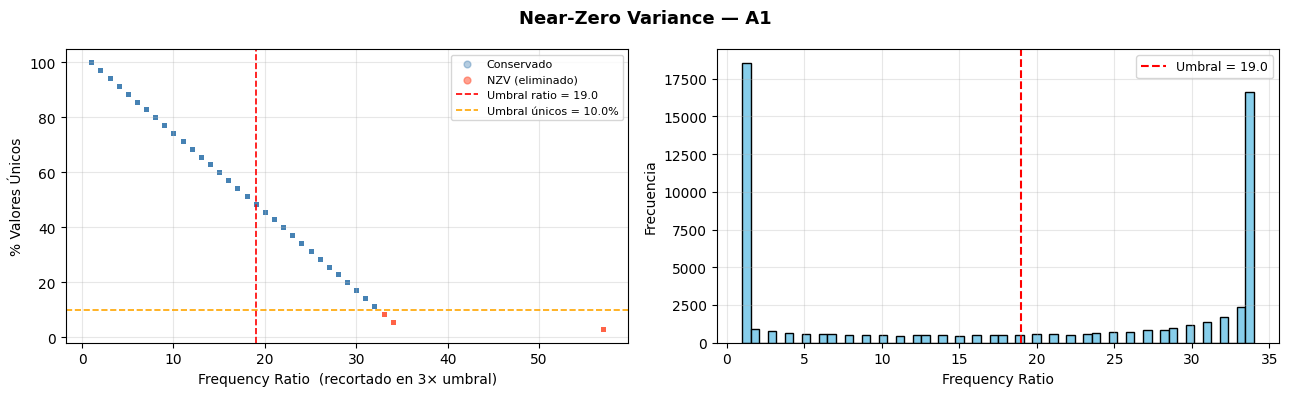


Dataset: A2
  NZV — genes evaluados : 58,735
  NZV — genes eliminados: 23,362  (freq_ratio > 19.0, % únicos < 10.0%)
  NZV — genes retenidos : 35,373


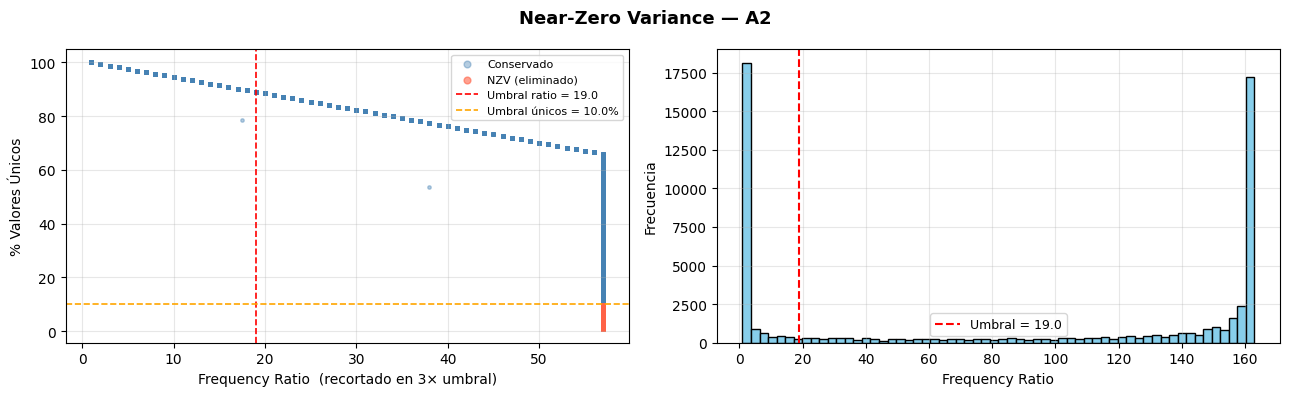


Dataset: B1
  NZV — genes evaluados : 58,735
  NZV — genes eliminados: 16,716  (freq_ratio > 19.0, % únicos < 10.0%)
  NZV — genes retenidos : 42,019


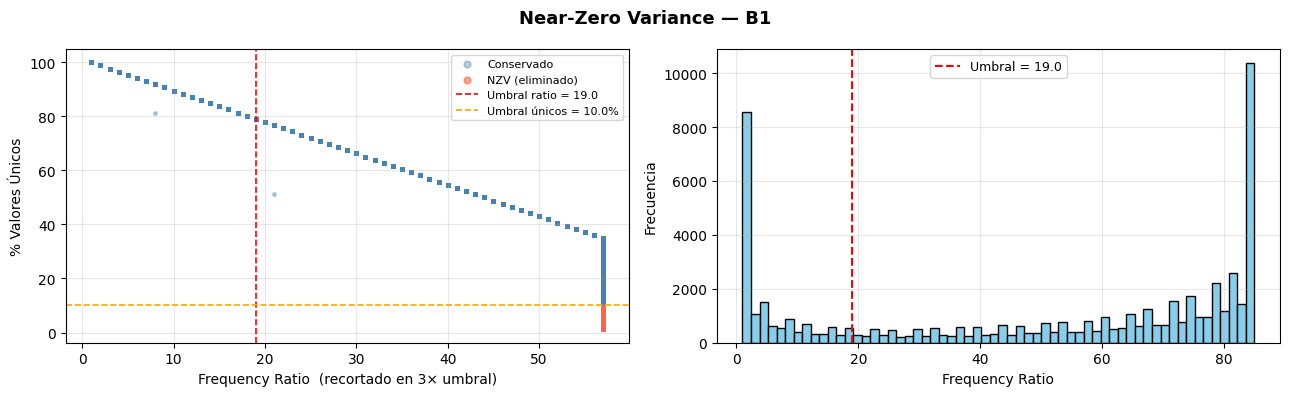


Dataset: B2
  NZV — genes evaluados : 58,148
  NZV — genes eliminados: 27,291  (freq_ratio > 19.0, % únicos < 10.0%)
  NZV — genes retenidos : 30,857


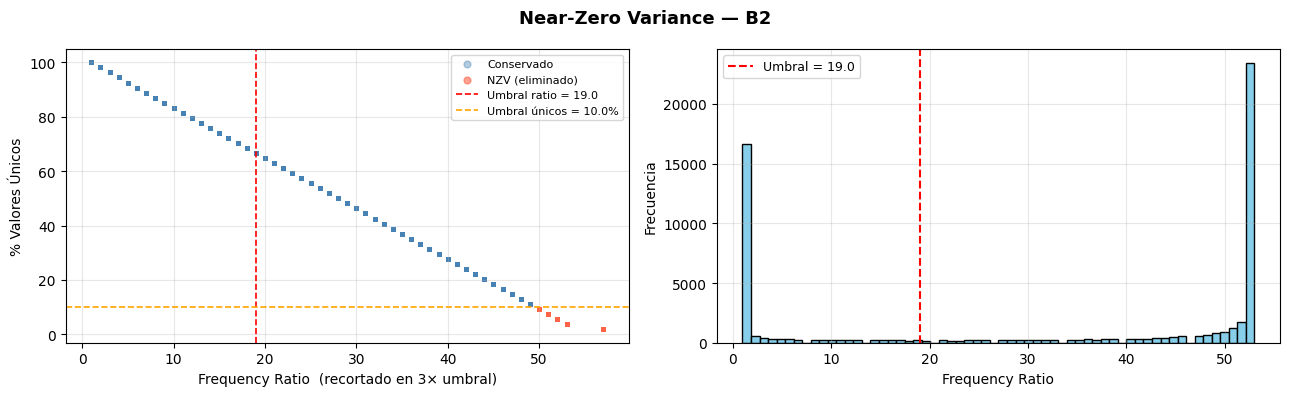


Dataset: B3
  NZV — genes evaluados : 58,735
  NZV — genes eliminados: 11,351  (freq_ratio > 19.0, % únicos < 10.0%)
  NZV — genes retenidos : 47,384


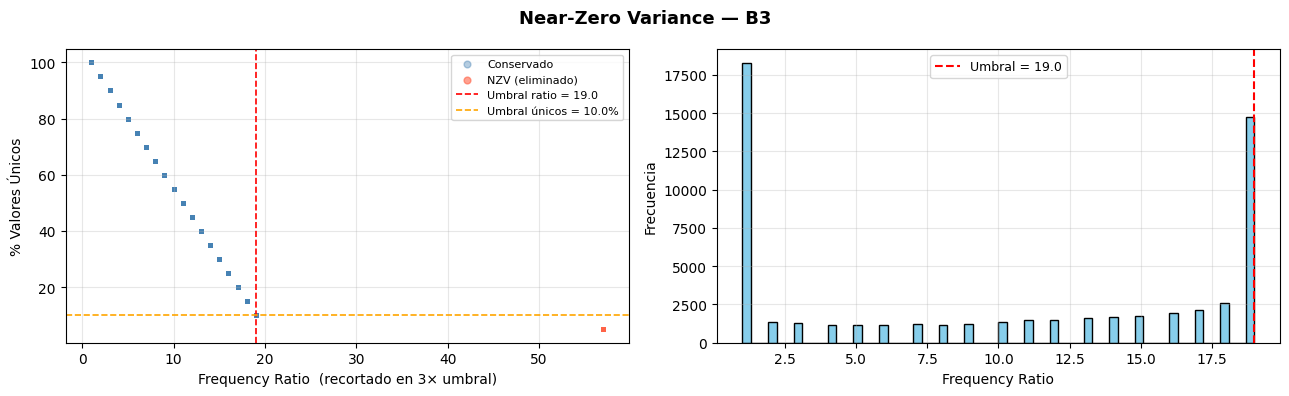


Dataset : A1


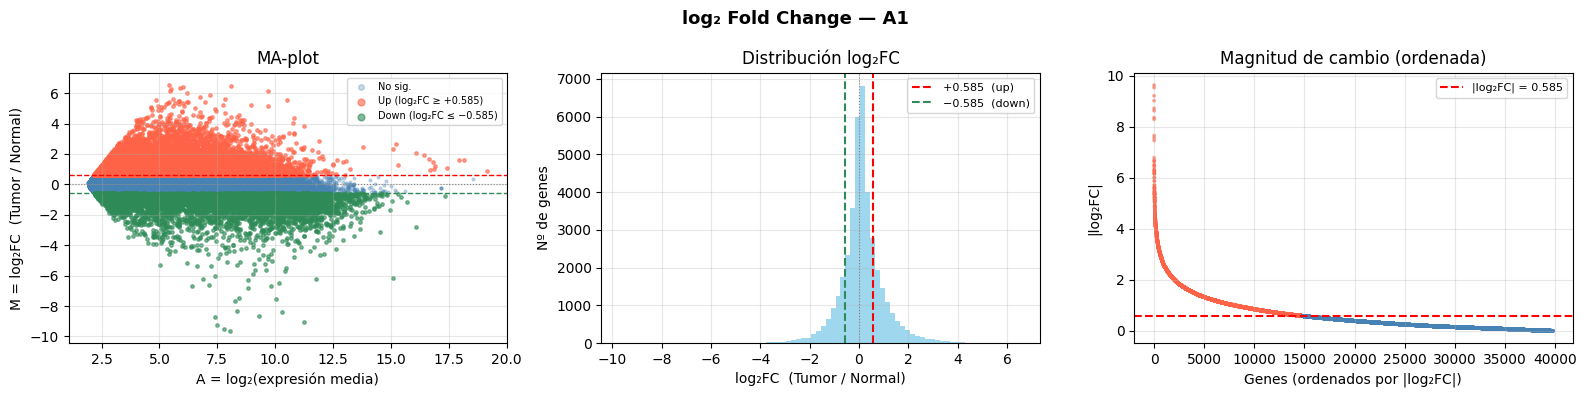

  Genes entrada      : 39,750
  Genes retenidos    : 14,808  (|log₂FC| ≥ 0.585)
    ↑ Up-regulated   :  8,839  (log₂FC ≥ +0.585)
    ↓ Down-regulated :  5,969  (log₂FC ≤ −0.585)
  log₂FC rango       : [-9.639,  6.523]

Dataset : A2


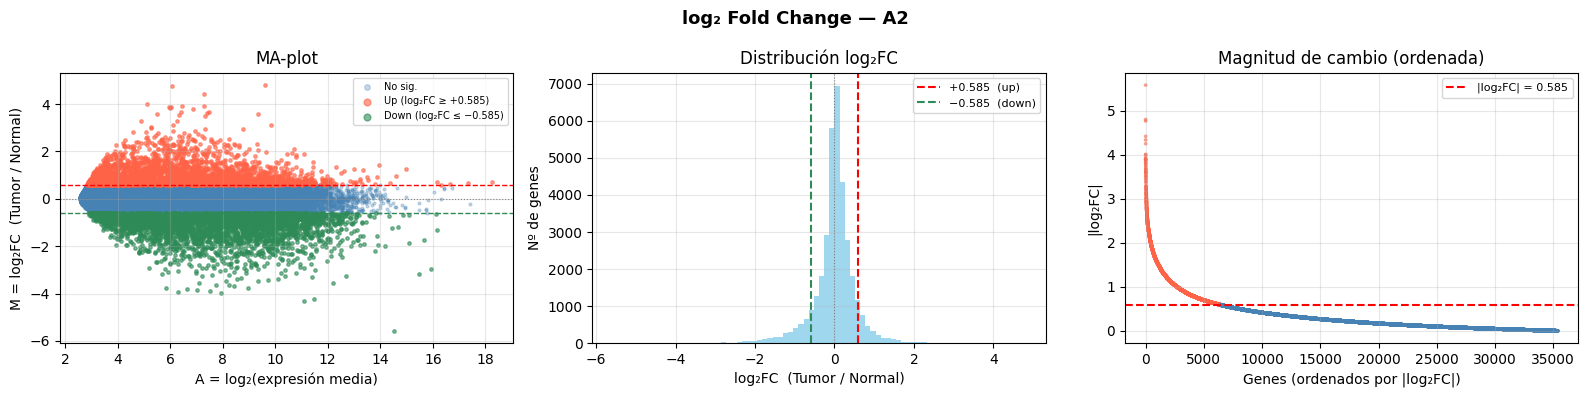

  Genes entrada      : 35,373
  Genes retenidos    :  6,498  (|log₂FC| ≥ 0.585)
    ↑ Up-regulated   :  2,993  (log₂FC ≥ +0.585)
    ↓ Down-regulated :  3,505  (log₂FC ≤ −0.585)
  log₂FC rango       : [-5.577,  4.798]

Dataset : B1


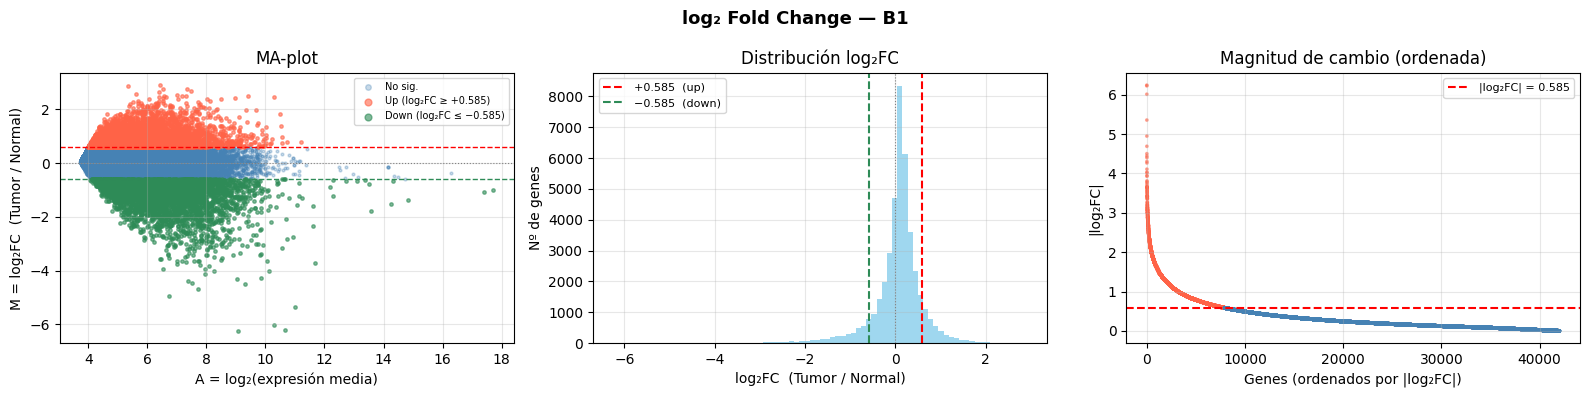

  Genes entrada      : 42,019
  Genes retenidos    :  7,935  (|log₂FC| ≥ 0.585)
    ↑ Up-regulated   :  4,257  (log₂FC ≥ +0.585)
    ↓ Down-regulated :  3,678  (log₂FC ≤ −0.585)
  log₂FC rango       : [-6.241,  2.899]

Dataset : B2


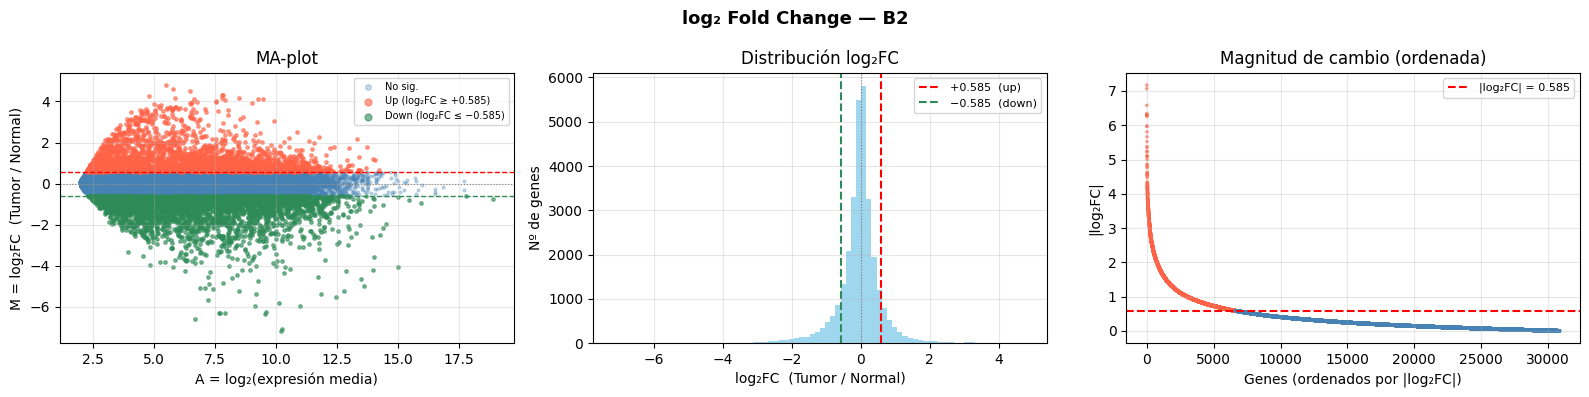

  Genes entrada      : 30,857
  Genes retenidos    :  6,650  (|log₂FC| ≥ 0.585)
    ↑ Up-regulated   :  2,962  (log₂FC ≥ +0.585)
    ↓ Down-regulated :  3,688  (log₂FC ≤ −0.585)
  log₂FC rango       : [-7.170,  4.797]

Dataset : B3


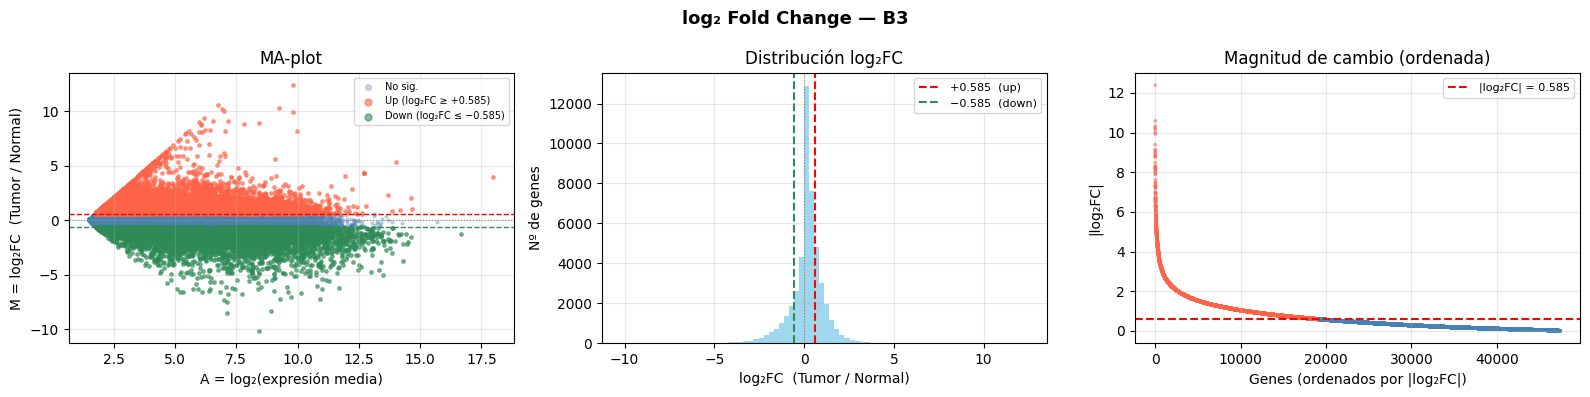

  Genes entrada      : 47,384
  Genes retenidos    : 19,283  (|log₂FC| ≥ 0.585)
    ↑ Up-regulated   : 12,436  (log₂FC ≥ +0.585)
    ↓ Down-regulated :  6,847  (log₂FC ≤ −0.585)
  log₂FC rango       : [-10.147,  12.395]


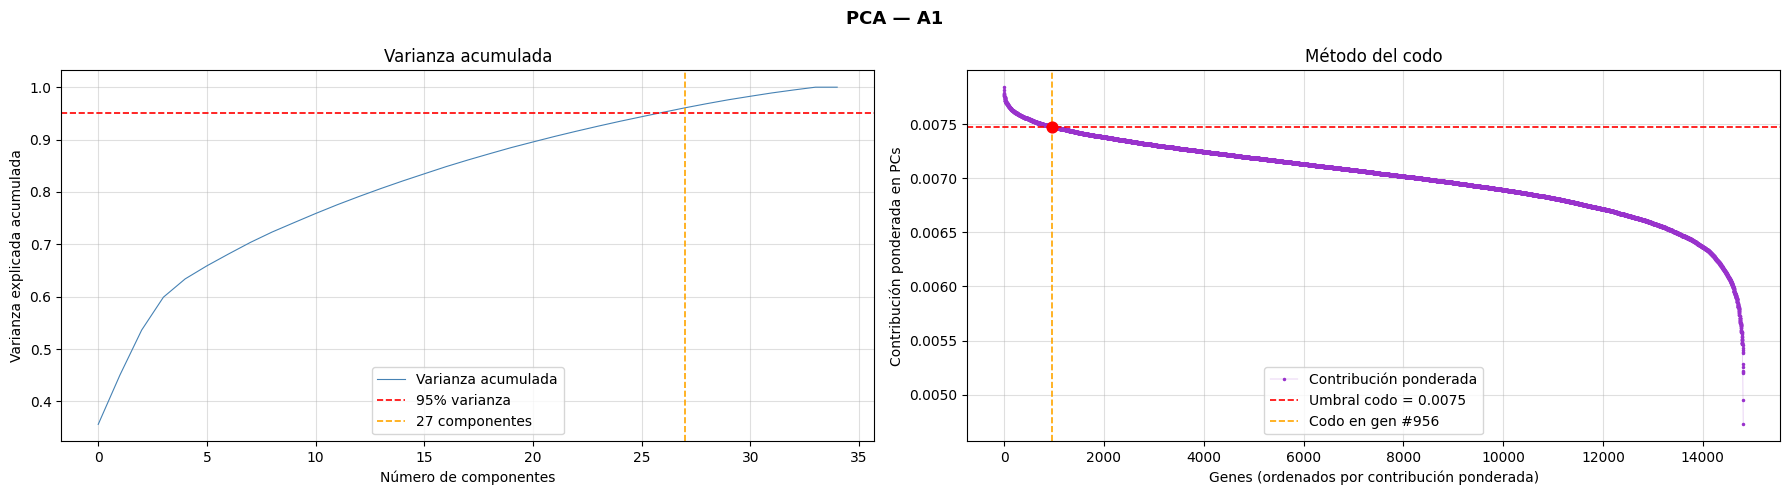

Dataset : A1
  PCs para 95% varianza : 27
  Umbral detectado (codo)      : 0.0075
  Genes entrada                : 14,808
  Genes retenidos              :    957  (6.5%)


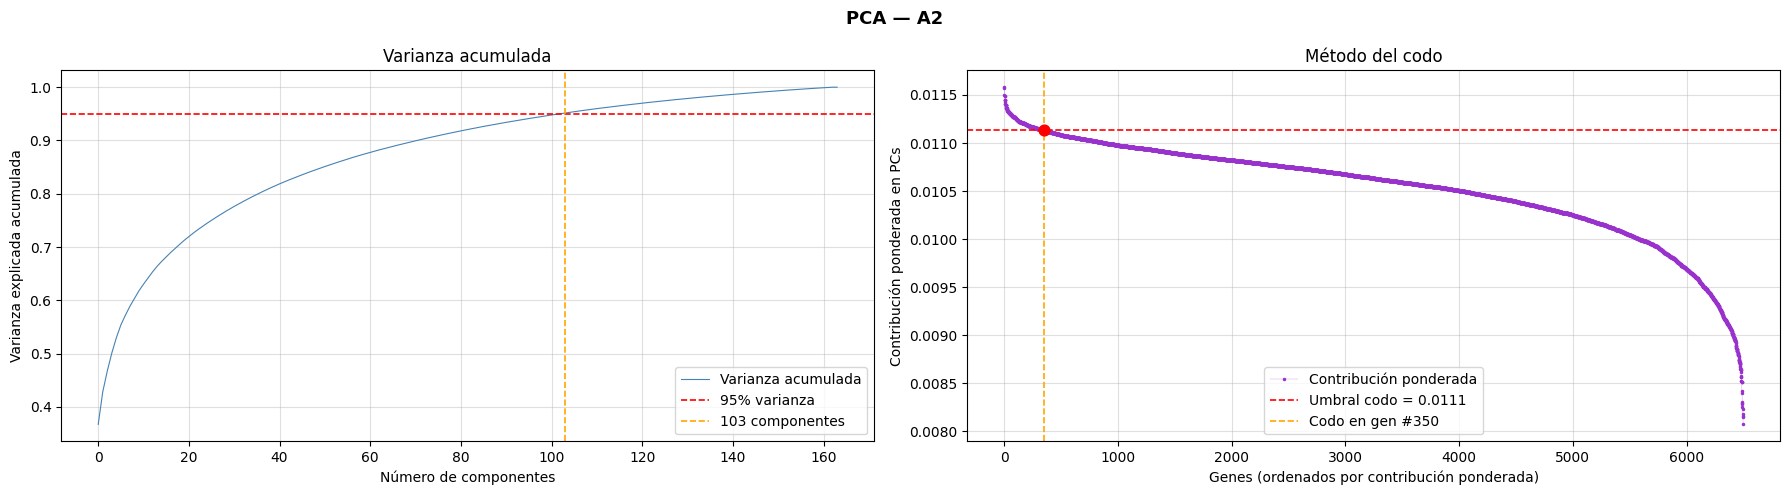

Dataset : A2
  PCs para 95% varianza : 103
  Umbral detectado (codo)      : 0.0111
  Genes entrada                :  6,498
  Genes retenidos              :    351  (5.4%)


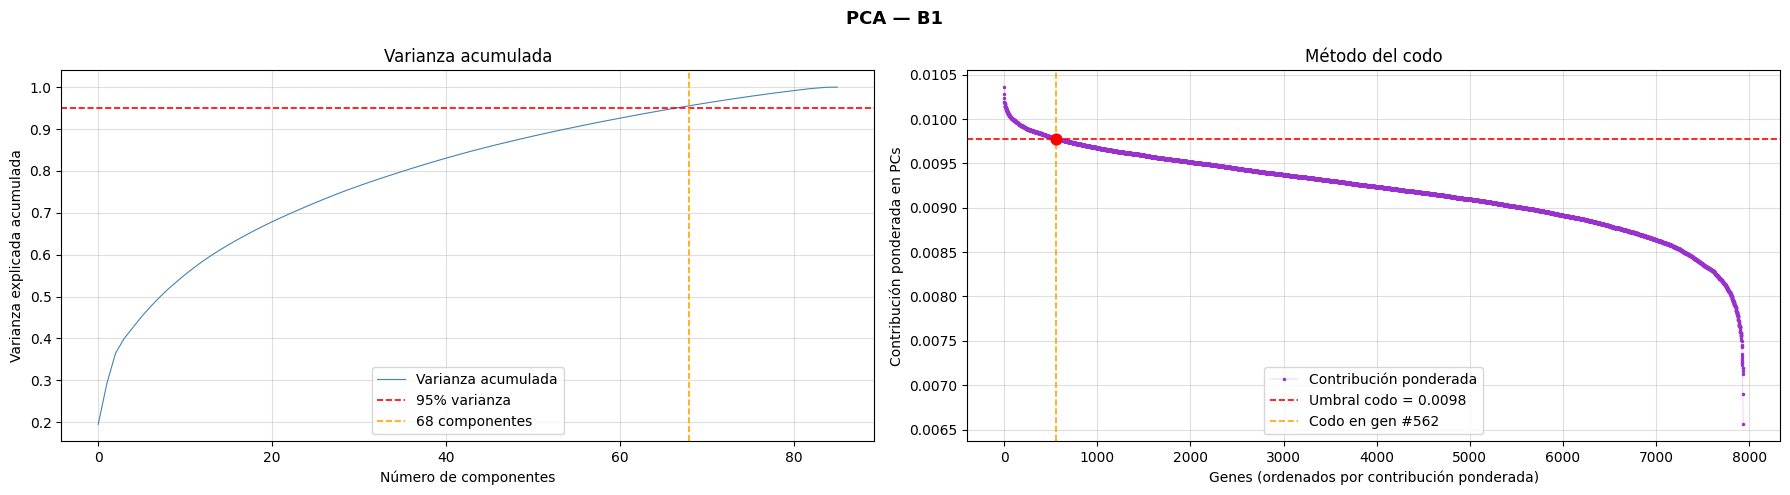

Dataset : B1
  PCs para 95% varianza : 68
  Umbral detectado (codo)      : 0.0098
  Genes entrada                :  7,935
  Genes retenidos              :    563  (7.1%)


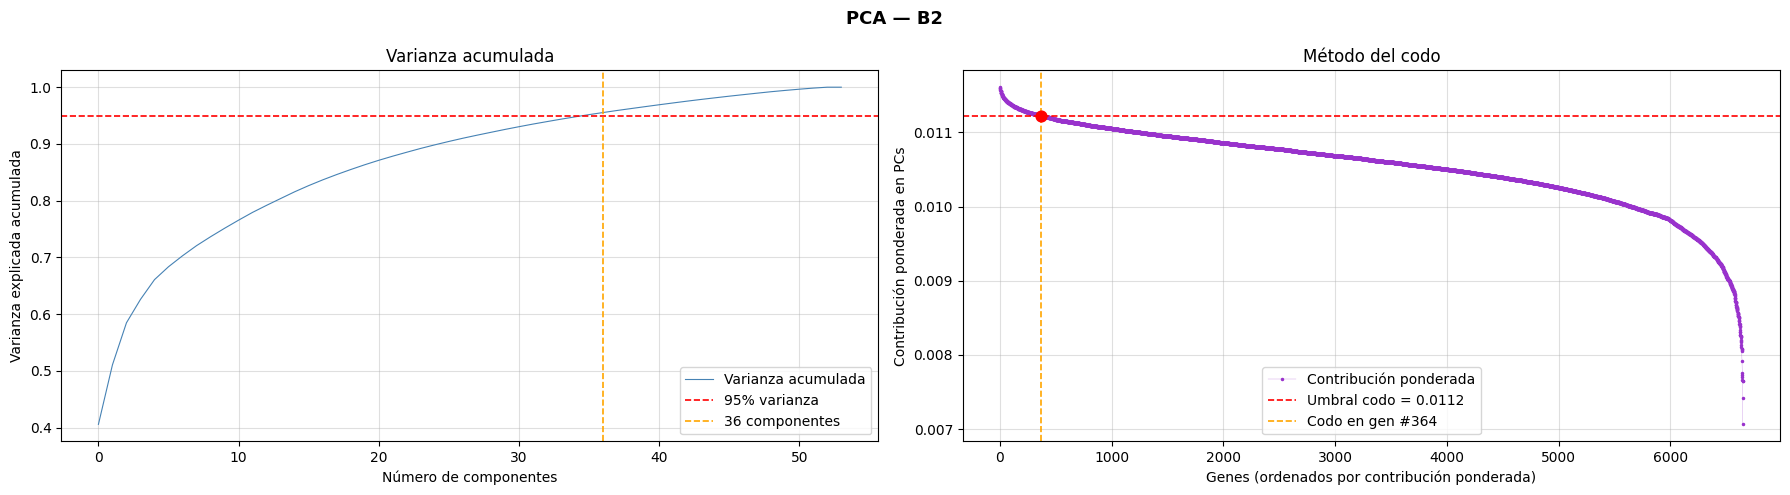

Dataset : B2
  PCs para 95% varianza : 36
  Umbral detectado (codo)      : 0.0112
  Genes entrada                :  6,650
  Genes retenidos              :    365  (5.5%)


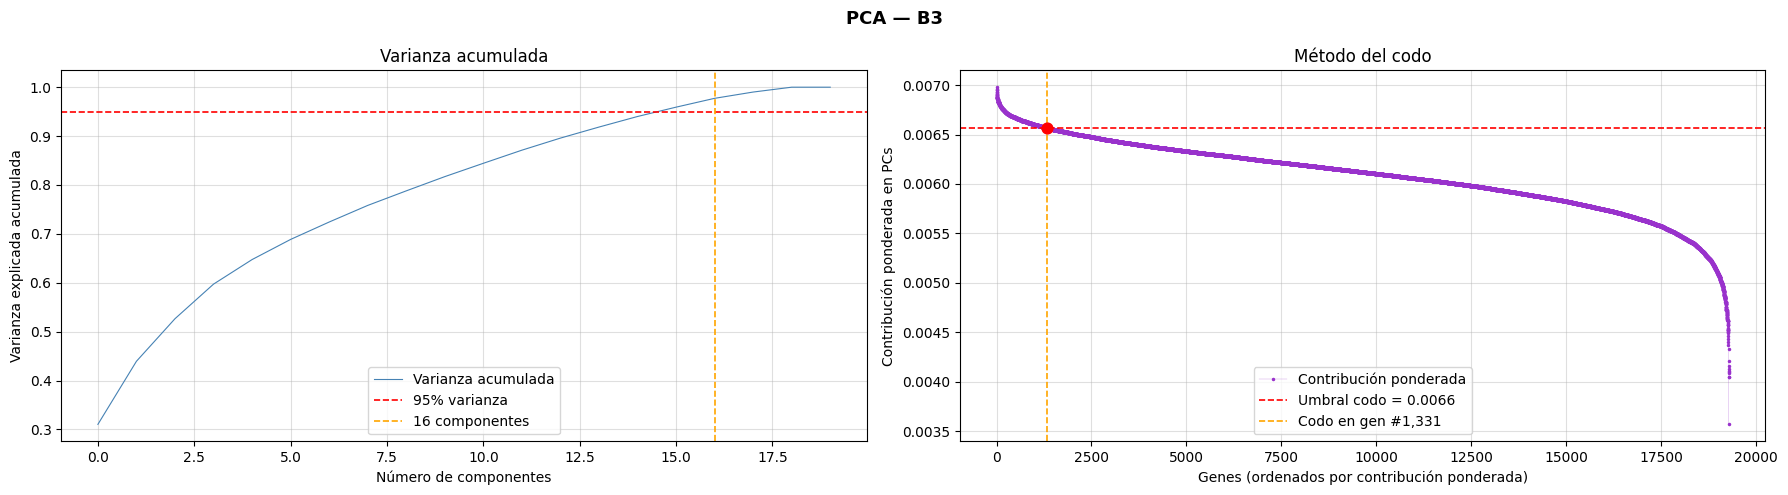

Dataset : B3
  PCs para 95% varianza : 16
  Umbral detectado (codo)      : 0.0066
  Genes entrada                : 19,283
  Genes retenidos              :  1,332  (6.9%)

  RESUMEN PIPELINE: NZV → FC → PCA (codo)

A1
  Original  : 58,735 genes
  Post-NZV  : 39,750 genes  (67.7%)
  Post-FC   : 14,808 genes  (25.2%)
  Post-PCA  :    957 genes  (1.6%)  umbral = 0.0075

A2
  Original  : 58,735 genes
  Post-NZV  : 35,373 genes  (60.2%)
  Post-FC   :  6,498 genes  (11.1%)
  Post-PCA  :    351 genes  (0.6%)  umbral = 0.0111

B1
  Original  : 58,735 genes
  Post-NZV  : 42,019 genes  (71.5%)
  Post-FC   :  7,935 genes  (13.5%)
  Post-PCA  :    563 genes  (1.0%)  umbral = 0.0098

B2
  Original  : 58,148 genes
  Post-NZV  : 30,857 genes  (53.1%)
  Post-FC   :  6,650 genes  (11.4%)
  Post-PCA  :    365 genes  (0.6%)  umbral = 0.0112

B3
  Original  : 58,735 genes
  Post-NZV  : 47,384 genes  (80.7%)
  Post-FC   : 19,283 genes  (32.8%)
  Post-PCA  :  1,332 genes  (2.3%)  umbral = 0.0066


In [4]:
%time

############################
# Ejecución
############################

# Paso 1 - Preparación de datasets con resultados finales en cada proceso.
DATASETS_NUMPY = {}
DATASETS_NZV   = {}
DATASETS_FC    = {}
DATASETS_PCA   = {}

# Paso 2 - Cambio de dataframes a matrices numpy para calculos vectorizados. 
for nombre, df in DATASETS.items():
    # Obtenición e metadata (Se eliminan espacios extra).
    df.columns  = df.columns.str.strip()
    df['ID']    = df['ID'].str.strip()
    df['class'] = df['class'].str.strip()

    # Se extraen todas las columnas de genes y se convierten
    # los datos numéricos a formato de Numpy (calculo vectorizado).
    cols_genes = [c for c in df.columns if c not in ['ID', 'class']]
    dataX   = df[cols_genes].to_numpy()

    # Codificación de columna de clase como vector binario
    # 0: Normal - 1: Tumor.
    targetY = np.where(df['class'] == 'Normal', 0, 1)

    # Alineamiento para correspondencia gen-columna mediante
    # índices enteros.
    genes   = np.array(cols_genes)
    ids     = df['ID'].to_numpy()

    # Empaquetado final.
    DATASETS_NUMPY[nombre] = {
        'dataX'  : dataX,
        'targetY': targetY,
        'genes'  : genes,
        'ids'    : ids
    }

# Paso 3 - Filtrado según criterios de NVZ. 
for nombre, datos in DATASETS_NUMPY.items():
    dataX = datos['dataX']
    genes = datos['genes']

    print(f"\n{'='*50}")
    print(f"Dataset: {nombre}")

    mascara_nzv, metricas = near_zero_var(
        dataX, genes,
        freq_cut   = 19.0,   # 95/5 — umbral estándar Kuhn (2013)
        unique_cut = 10.0,   # < 10% valores únicos
        verbose    = True
    )

    plot_nzv(metricas, nombre, freq_cut=19.0, unique_cut=10.0)

    dataX_nzv = dataX[:, mascara_nzv]
    genes_nzv = genes[mascara_nzv]

    DATASETS_NZV[nombre] = {
        **datos,
        'dataX'      : dataX_nzv,
        'genes'      : genes_nzv,
        'mascara_nzv': mascara_nzv,
        'metricas_nzv': metricas
    }

# Paso 4 - Filtrado según criterio de fold-change
# Umbral estándar: |log₂FC| ≥ 1  ↔  cambio ≥ 2× en escala lineal. Se puede 
# ajustar a 0.585 (1.5×) para criterio más permisivo.
UMBRAL_LOG2FC = 0.585

for nombre, datos in DATASETS_NZV.items():          # ← entrada: post-NZV
    dataX  = datos['dataX']
    targetY = datos['targetY']
    genes  = datos['genes']

    print(f"\n{'='*55}")
    print(f"Dataset : {nombre}")

    log2fc, media_normal, media_tumor = calcular_log2fc(dataX, targetY)

    plot_log2fc(log2fc, media_normal, media_tumor, genes,
                nombre, umbral_fc=UMBRAL_LOG2FC)

    # ── Filtro bidireccional: genes con cambio relevante en CUALQUIER dirección
    mascara_fc = np.abs(log2fc) >= UMBRAL_LOG2FC
    dataX_fc   = dataX[:, mascara_fc]
    genes_fc   = genes[mascara_fc]

    n_up   = np.sum(log2fc[mascara_fc] > 0)
    n_down = np.sum(log2fc[mascara_fc] < 0)

    print(f"  Genes entrada      : {dataX.shape[1]:>6,}")
    print(f"  Genes retenidos    : {dataX_fc.shape[1]:>6,}  (|log₂FC| ≥ {UMBRAL_LOG2FC})")
    print(f"    ↑ Up-regulated   : {n_up:>6,}  (log₂FC ≥ +{UMBRAL_LOG2FC})")
    print(f"    ↓ Down-regulated : {n_down:>6,}  (log₂FC ≤ −{UMBRAL_LOG2FC})")
    print(f"  log₂FC rango       : [{log2fc.min():.3f},  {log2fc.max():.3f}]")

    DATASETS_FC[nombre] = {
        **datos,
        'dataX'       : dataX_fc,
        'genes'       : genes_fc,
        'log2fc'      : log2fc,       # vector completo (pre-filtro) para trazabilidad
        'mascara_fc'  : mascara_fc,
        'media_normal': media_normal,
        'media_tumor' : media_tumor,
    }

# Paso 5 - Filtrado según uso de PCA.
for nombre, datos in DATASETS_FC.items():
    resultado_pca = processing_pca(datos['dataX'], datos['genes'], nombre)
    DATASETS_PCA[nombre] = {**datos, **resultado_pca}

# ============================================================
# RESUMEN FINAL — pipeline NZV → FC → PCA
# ============================================================
separador = '=' * 55
print(f"\n{separador}")
print("  RESUMEN PIPELINE: NZV → FC → PCA (codo)")
print(separador)

for nombre in DATASETS_NUMPY:
    n0 = DATASETS_NUMPY[nombre]['dataX'].shape[1]
    n1 = DATASETS_NZV[nombre]['dataX'].shape[1]
    n2 = DATASETS_FC[nombre]['dataX'].shape[1]
    n3 = DATASETS_PCA[nombre]['dataX'].shape[1]
    u  = DATASETS_PCA[nombre]['umbral_contrib']

    print(f"\n{nombre}")
    print(f"  Original  : {n0:>6,} genes")
    print(f"  Post-NZV  : {n1:>6,} genes  ({n1/n0*100:.1f}%)")
    print(f"  Post-FC   : {n2:>6,} genes  ({n2/n0*100:.1f}%)")
    print(f"  Post-PCA  : {n3:>6,} genes  ({n3/n0*100:.1f}%)  umbral = {u:.4f}")

## Reconocimiento de identificadores de genes

<div style="text-align: justify;">

Dentro de la presente sección se realiza el filtrado y emparejamiento de los identificadores `ENSG` existentes en los _datasets_ resultantes del proceso de _feature selection_, mediante la siguiente secuencia de pasos:

1. **Descarga de información:** Se descargan los documentos pertenecientes al servidor _FTP_ de `Ensembl` junto al de `NCBI` para el mapeo de genes y, aprovechando este paso, se descargan también los archivos de información de _Gene Ontology_ necesarios para el cálculo del índice de Wang.
2. **Reconocimiento de identificadores obsoletos:** Se eliminan todos los `ENSG` que la base de datos reconozca como retirados de forma permanente (_deprecated_) dentro de la base de conocimiento. Paralelamente, se asegura el reemplazo de aquellos `ENSG` que se encuentren desactualizados por su identificador vigente.
3. **Emparejamiento con _Entrez ID_:** Mediante la información descargada del _FTP_ de `Ensembl` y el uso de la función `convert_to_entrez_id` del paquete `biocluster`, se realiza el emparejamiento del **menor** _Entrez ID_ asociado a cada identificador `ENSG`.
4. **Reducción de dataframe:** Una vez completado el reconocimiento de estas equivalencias, se resuelven los duplicados y se reducen los conjuntos de datos reemplazando cada `ENSG` por su correspondiente _Entrez ID_.

Respecto a la información que se consulta dentro de los archivo, las Tablas 3 a 7 presentan las especificaciones de cada una:

**Tabla 3:** Especificaciones del archivo _stable_id_event.txt_ (Fuente: [ensembl_docs_info](https://may2009.archive.ensembl.org/info/docs/api/core/schema/index.html#stable_id_event)).
|        Campo       |                                                           Descripción                                                          |
|--------------------|--------------------------------------------------------------------------------------------------------------------------------|
|    old_stable_id   | Identificador estable (_stable ID_) anterior al evento de mapeo, correspondiente a la versión previa del genoma de referencia. |
|     old_version    | Número de versión asociado al identificador estable anterior (_old\_stable\_id_).                                              |
|    new_stable_id   | Identificador estable resultante tras el evento de mapeo, correspondiente a la versión vigente del genoma de referencia.       |
|     new_version    | Número de versión asociado al nuevo identificador estable (_new\_stable\_id_).                                                 |
| mapping_session_id | Identificador de la sesión de mapeo (_mapping session_) en la cual se registró la transición entre el identificador antiguo y el nuevo, permitiendo asociar el evento a un ensamblaje y lanzamiento (_release_) específico de Ensembl. |
|        type        | Tipo de entidad biológica a la que corresponde el identificador (gen, transcrito, traducción o exón).                          |
|        score       | Puntaje de confianza (entre 0 y 1) que cuantifica el grado de similitud o correspondencia entre el identificador antiguo y el nuevo durante el proceso de mapeo. |


**Tabla 4:** Especificaciones Homo_sapiens _entrez.tsv_ y _uniprot.tsv_ (Fuente: [ensembl_docs_info](https://may2009.archive.ensembl.org/info/docs/api/core/schema/index.html#stable_id_event)).
|         Campo        |                                                           Descripción                                                          |
|----------------------|--------------------------------------------------------------------------------------------------------------------------------|
|    gene_stable_id    | Identificador estable (_ENSG_) del gen en Ensembl al cual se asocia la referencia externa (_xref_).                            |
| transcript_stable_id | Identificador estable (_ENST_) del transcrito en Ensembl asociado al gen y a la referencia externa correspondiente.            |
|   protein_stable_id  | Identificador estable (_ENSP_) de la proteína en Ensembl asociada al transcrito y a la referencia externa correspondiente.     |
|         xref         | Identificador de la referencia externa (por ejemplo, _Entrez ID_ o _UniProt ID_) vinculado al identificador estable de Ensembl.|
|        db_name       | Nombre de la base de datos externa de origen de la referencia (por ejemplo, _EntrezGene_ o _UniProtKB/Swiss-Prot_).            |
|       info_type      | Tipo de evidencia o método mediante el cual se estableció la asociación entre el identificador de Ensembl y la referencia externa (por ejemplo, _DIRECT_, _SEQUENCE_MATCH_ o _DEPENDENT_). |
|     xref_identity    | Porcentaje de identidad de secuencia entre el identificador de Ensembl y la referencia externa, cuando la asociación se determinó mediante alineamiento de secuencias. |
|     linkage_type     | Tipo de vínculo o fuente que originó la asociación entre el identificador de Ensembl y la referencia externa (por ejemplo, anotación manual o inferencia automática). |

**Tabla 5:** Especificaciones de archivo _gene.info_ (Fuente: [ncbi_docs](https://ftp.ncbi.nih.gov/gene/DATA/README)).
|                  Campo                | Descripción |
|---------------------------------------|-------------|
|                 tax_id                | Identificador taxonómico (_taxonomy ID_) del organismo al que pertenece el gen (por ejemplo, 9606 para _Homo sapiens_). |
|                 GeneID                | Identificador único del gen asignado por NCBI (_Entrez Gene ID_). |
|                 Symbol                | Símbolo oficial del gen, correspondiente a la nomenclatura del organismo. |
|                LocusTag               | Etiqueta de locus (_locus tag_) asignada al gen, utilizada principalmente en genomas procariontes o de referencia sistemática. |
|                Synonyms               | Lista de símbolos alternativos o sinónimos conocidos del gen, separados por el carácter `\|`. |
|                 dbXrefs               | Referencias cruzadas (_cross-references_) a identificadores del gen en otras bases de datos externas (por ejemplo, Ensembl, HGNC, MIM), separadas por `\|`. |
|               chromosome              | Cromosoma en el cual se localiza el gen. |
|              map_location             | Ubicación citogenética del gen dentro del cromosoma (banda cromosómica). |
|               description             | Nombre o descripción funcional completa del gen. |
|              type_of_gene             | Categoría biológica del gen (por ejemplo, _protein-coding_, _pseudo_, _ncRNA_). |
|   Symbol_from_nomenclature_authority  | Símbolo oficial del gen según la autoridad de nomenclatura correspondiente (por ejemplo, HGNC para humanos). |
| Full_name_from_nomenclature_authority | Nombre completo del gen según la autoridad de nomenclatura oficial. |
|           Nomenclature_status         | Estado de la nomenclatura del símbolo (_O_ para oficial, _I_ para provisional). |
|           Other_designations          | Otras designaciones o nombres alternativos del gen no incluidos como sinónimos oficiales, separados por `\|`. |
|           Modification_date           | Fecha de la última modificación del registro, en formato _YYYYMMDD_. |
|             Feature_type              | Tipo de característica genómica asociada al registro (cuando aplica). |

**Tabla 6:** Especificaciones de archivo _.gaf_ (Fuente: [GO_gaf](https://geneontology.org/docs/go-annotation-file-gaf-format-2.2/)).

| #  |   Nombre de columna  |                                       Descripción                                       |
|----|----------------------|-----------------------------------------------------------------------------------------|
| 1  |           DB         | Base de datos que proporciona la anotación (p. ej. `UniProtKB`, `SGD`)                  |
| 2  |     DB Object ID     | Identificador único del gen/proteína anotado en dicha base de datos (p. ej. `P12345`)   |
| 3  |   DB Object Symbol   | Símbolo del gen o proteína (p. ej. `CDK2`)                                              |
| 4  |       Qualifier      | Modifica la anotación: `NOT`, `contributes_to` o `colocalizes_with`                     |
| 5  |         GO ID        | Identificador (_accession_) del término GO (p. ej. `GO:0006281`)                                               |
| 6  |     DB:Reference     | Publicación o referencia de base de datos que respalda la anotación (p. ej. `PMID:12345678`)      |
| 7  |     Evidence Code    | Código de tres letras que indica el tipo de evidencia (ver tabla siguiente)                         |
| 8  |       With/From      | Identificador adicional utilizado con ciertos códigos de evidencia (p. ej. secuencia utilizada para ISS)     |
| 9  |        Aspect        | Dominio de GO: `P` (Proceso Biológico), `F` (Función Molecular), `C` (Componente Celular) |
| 10 |    DB Object Name    | Nombre completo del producto génico (p. ej. `Cyclin-dependent kinase 2`)                        |
| 11 |   DB Object Synonym  | Símbolos o identificadores alternativos, separados por el carácter `\|`                                                |
| 12 |    DB Object Type    | Tipo de entidad: `protein`, `gene`, `RNA`, `protein_complex`, entre otros                          |
| 13 |        Taxon         | Identificador(es) de taxonomía de NCBI del organismo (p. ej. `taxon:9606`)                                 |
| 14 |         Date         | Fecha de la anotación en formato `YYYYMMDD`                                                    |
| 15 |      Assigned By     | Base de datos o grupo que realizó la anotación (p. ej. `GOC`, `UniProt`)                      |
| 16 | Annotation Extension | Extiende la anotación con relaciones a otros términos o identificadores de la ontología                    |
| 17 | Gene Product Form ID | Isoforma específica o forma modificada (p. ej. un identificador de isoforma de UniProtKB)                         |

| Código |   Categoría    |                            Significado                            |
|------|---------------|---------------------------------------------------------------|
| EXP  | Experimental  | Inferido a partir de un experimento                                      |
| IDA  | Experimental  | Inferido a partir de ensayo directo                                    |
| IPI  | Experimental  | Inferido a partir de interacción física                            |
| IMP  | Experimental  | Inferido a partir de fenotipo mutante                              |
| IGI  | Experimental  | Inferido a partir de interacción genética                             |
| IEP  | Experimental  | Inferido a partir de patrón de expresión                              |
| ISS  | Computacional | Inferido a partir de similitud de secuencia o estructural               |
| ISO  | Computacional | Inferido a partir de ortología de secuencia                              |
| ISA  | Computacional | Inferido a partir de alineamiento de secuencia                              |
| ISM  | Computacional | Inferido a partir de modelo de secuencia                                  |
| IGC  | Computacional | Inferido a partir de contexto genómico                             |
| IBA  | Filogenético  | Inferido a partir de aspecto biológico del ancestro                   |
| IBD  | Filogenético  | Inferido a partir de aspecto biológico del descendiente                 |
| IKR  | Filogenético  | Inferido a partir de residuos clave                                    |
| IRD  | Filogenético  | Inferido a partir de divergencia rápida                                |
| RCA  | Computacional | Inferido a partir de análisis computacional revisado                 |
| TAS  | Literatura    | Declaración de autor rastreable                                    |
| NAS  | Literatura    | Declaración de autor no rastreable                                |
| IC   | Curador       | Inferido por curador                                           |
| ND   | Sin datos     | No hay datos biológicos disponibles                                  |
| IEA  | Automático    | Inferido mediante anotación electrónica (no revisado manualmente)   |

> **Nota:** `IEA` es el único código de evidencia que **no** requiere una referencia bibliográfica y se excluye de los conteos de anotación manual. Las anotaciones que utilizan `NOT` en la columna 4 indican explícitamente que el producto génico *no* está asociado al término GO indicado, lo cual es importante para evitar transferencias de falsos positivos entre especies.

**Tabla 7:** Especificaciones archivo _go.obo_ (Fuente: [GO_obo](https://geneontology.org/docs/ontology-documentation/))
|           Campo           | Descripción |
|---------------------------|-------------|
|         Accession         | Identificador único del término dentro de _Gene Ontology_ (por ejemplo, `GO:0008150`), utilizado como referencia estándar del término en las tres categorías (BP, MF, CC). |
|         Term name         | Nombre descriptivo y legible del término de GO asociado al identificador (_Accession_). |
|         Definition        | Descripción textual formal del significado del término, generalmente acompañada de referencias bibliográficas o de bases de datos que respaldan dicha definición. |
|        Alternate ID       | Identificadores alternativos (`alt_id`) que corresponden a términos fusionados o reemplazados por el término actual tras actualizaciones de la ontología, manteniendo la trazabilidad histórica. |
|         Synonyms          | Sinónimos del término según su grado de equivalencia semántica: _Exact_, _Broad_, _Narrow_, _Related_ y _Custom synonym_. |
|          Comment          | Notas adicionales sobre el uso, alcance o consideraciones especiales del término, incluidas por los curadores de GO. |
|        Chem. react.       | Referencias a reacciones químicas asociadas al término, relevantes principalmente en términos vinculados a procesos metabólicos o funciones enzimáticas. |
|           Subset          | Subconjunto (_subset_) de la ontología al que pertenece el término, utilizado para agrupar términos según vistas simplificadas o de uso específico (por ejemplo, `goslim_generic`). |
|        Obsolete tag       | Marca que indica si el término ha sido declarado obsoleto (`is_obsolete: true`) y, en tal caso, referencia el o los términos recomendados como reemplazo (`consider` o `replaced_by`). |
|     Taxon constraints     | Restricciones taxonómicas que indican en qué organismos (taxones) el término es aplicable o, por el contrario, en cuáles no puede utilizarse. |
| Database cross-references | Referencias cruzadas (`xref`) a identificadores equivalentes o relacionados en otras bases de datos externas (por ejemplo, KEGG, Reactome, UniProt). |

</div>

In [5]:
############################
# Importaciones
############################
from biocluster.go.mapping_entrez import MappingOptions         # Configuración de función.
from biocluster.go.mapping_entrez import convert_to_entrez_id   # Convertir cualquier símbolo a Entrez ID.

############################
# Detalle de archivos descargados
############################
# Fecha: 05-09-2026 (Se mantiene copia en repositorio).
# 1. stable_id_event.txt                 -> https://ftp.ensembl.org/pub/release-116/mysql/homo_sapiens_core_116_38/stable_id_event.txt.gz
# 2. Homo_sapiens.GRCh38.116.entrez.tsv  -> https://ftp.ensembl.org/pub/release-116/tsv/homo_sapiens/Homo_sapiens.GRCh38.116.entrez.tsv.gz
# 3. Homo_sapiens.GRCh38.116.uniprot.tsv -> https://ftp.ensembl.org/pub/release-116/tsv/homo_sapiens/Homo_sapiens.GRCh38.116.uniprot.tsv.gz
# 4. Homo_sapiens.gene_info              -> https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz
# 5. go.obo                              -> https://purl.obolibrary.org/obo/go.obo
# 6. HUMAN-uniprot.gaf                   -> https://current.geneontology.org/annotations/gaf/HUMAN-uniprot.gaf.gz 

############################
# Constantes
############################
DEPRECATED_DIR = Path(os.getcwd()).resolve().parent / "Datasets" / "Bio_Info Resources" / "stable_id_event.txt"
ENTREZ_DIR     = Path(os.getcwd()).resolve().parent / "Datasets" / "Bio_Info Resources" / "Homo_sapiens.GRCh38.116.entrez.tsv"
UNIPROT_DIR    = Path(os.getcwd()).resolve().parent / "Datasets" / "Bio_Info Resources" / "Homo_sapiens.GRCh38.116.uniprot.tsv"

options = MappingOptions(
    organism_gp = "hsapiens", tax_id = 9606,
    scopes_mg = ("symbol", "alias", "tair", "accession", "refseq", "ensembl.gene"),
    na_value = "NA", n_threads = 8, chunk_size = 100,
    request_retries = 3, backoff_base_seconds = 0.6
)

############################
# Funciones
############################

# PASO 0 - Unión de todos los identificadores de genes asociados al PCA.
def processing_gene_union_post_pca(datasets_pca: dict) -> tuple[list, pd.DataFrame, pd.DataFrame]:
    """
    Función que encapsula la unión de los identificadores de genes
    resultantes del proceso de feature selection (DATASETS_PCA), generando
    una lista única y documentando el aporte de cada dataset a dicha unión.
    """
    # Se extraen los genes de cada conjunto individual y se hace el conjunto consolidado de los
    # identificadores únicos.
    gene_sets = {name: set(datos['genes']) for name, datos in datasets_pca.items()}
    union_genes = sorted(set.union(*gene_sets.values()))

    # Se evalua la presencia de cada identificador en los dataframes.
    presence_df = pd.DataFrame(
        {name: [gene in genes for gene in union_genes] for name, genes in gene_sets.items()},
        index=union_genes
    )
    presence_df.index.name = "gene_id"

    # Se genera calculos sobre el aporte de cada dataset al conjunto de genes consolidado.
    resumen_rows = []
    for name, genes in gene_sets.items():
        otros = set.union(*(g for n, g in gene_sets.items() if n != name))
        exclusivos = genes - otros
        resumen_rows.append({
            "Dataset":             name,
            "N° genes en dataset": len(genes),
            "N° genes exclusivos": len(exclusivos),
            "% aporte a la unión": round(100 * len(genes) / len(union_genes), 2),
        })
    resumen_df = pd.DataFrame(resumen_rows).sort_values("N° genes en dataset", ascending=False)

    return union_genes, presence_df, resumen_df

# PASO 2 - Procesamiento de identificadores obsoletos dentro del archivo stable_id_event.txt
def processing_deprecated_filter_iterative(
    gene_list: list, path_stable_id_event: str, max_iter: int = 20
) -> tuple[list, pd.DataFrame, pd.DataFrame, dict]:
    """
    Resuelve iterativamente los genes deprecados de gene_list, reemplazando
    en cada pasada aquellos que tengan un id de reemplazo directo, hasta que
    no queden más reemplazos posibles (convergencia) o se agote max_iter.

    Los genes que caen en un ciclo de mapeo se CONSERVAN, usando el último
    id válido antes de detectar el ciclo. Solo se elimina un gen si su
    cadena termina en un retiro permanente sin reemplazo (new_stable_id = NULL).
    """
    # Columnas asociadas al archivo (son implicitas).
    cols = ["old_stable_id", "old_version", "new_stable_id",
            "new_version", "mapping_session_id", "type", "score"]

    events = pd.read_csv(
        path_stable_id_event, sep="\t", names=cols, na_values=["\\N"],
        dtype={"old_stable_id": "string", "new_stable_id": "string", "type": "string"}
    )
    gene_events = events[events["type"] == "gene"]

    cadenas = {g: [g] for g in gene_list}
    activos = {g: g for g in gene_list}
    estado_final = {}
    log_iteraciones = []
    it = 0

    while it < max_iter and activos:
        it += 1
        ids_actuales = set(activos.values())
        relevant = gene_events[gene_events["old_stable_id"].isin(ids_actuales)]

        if relevant.empty:
            for orig in activos:
                estado_final[orig] = "vigente"
            activos = {}
            break

        idx_ultimo = relevant.groupby("old_stable_id")["mapping_session_id"].idxmax()
        mapa = dict(zip(
            relevant.loc[idx_ultimo, "old_stable_id"],
            relevant.loc[idx_ultimo, "new_stable_id"]
        ))

        n_vigentes, n_reemplazados, n_sin_reemplazo, n_ciclo = 0, 0, 0, 0
        siguientes_activos = {}

        for orig, actual in activos.items():
            if actual not in mapa:
                estado_final[orig] = "vigente"
                n_vigentes += 1
                continue

            nuevo_id = mapa[actual]

            if pd.isna(nuevo_id):
                estado_final[orig] = "sin_reemplazo"
                n_sin_reemplazo += 1
                continue

            if nuevo_id in cadenas[orig]:
                estado_final[orig] = "vigente_con_ciclo"
                n_ciclo += 1
                continue

            cadenas[orig].append(nuevo_id)
            siguientes_activos[orig] = nuevo_id
            n_reemplazados += 1

        log_iteraciones.append({
            "iteracion": it, "n_evaluados": len(activos), "n_vigentes": n_vigentes,
            "n_reemplazados": n_reemplazados, "n_sin_reemplazo": n_sin_reemplazo, "n_ciclo": n_ciclo,
        })
        activos = siguientes_activos

    for orig in activos:
        estado_final[orig] = "max_iter_excedido"

    historial_df = pd.DataFrame([
        {"id_original": orig, "id_final": cadena[-1], "n_saltos": len(cadena) - 1,
         "cambio": cadena[-1] != orig, "estado": estado_final[orig]}
        for orig, cadena in cadenas.items()
    ])
    log_df = pd.DataFrame(log_iteraciones)

    estados_conservados = {"vigente", "vigente_con_ciclo"}
    filtered_list = sorted(historial_df.loc[historial_df["estado"].isin(estados_conservados), "id_final"].unique())

    n_total = len(gene_list)
    resumen = {
        "N° genes en lista original":                n_total,
        "N° iteraciones ejecutadas":                  it,
        "N° genes vigentes":                          int((historial_df["estado"] == "vigente").sum()),
        "N° genes vigentes con ciclo (conservados)":  int((historial_df["estado"] == "vigente_con_ciclo").sum()),
        "N° genes renombrados":                       int((historial_df["estado"].isin(estados_conservados) & historial_df["cambio"]).sum()),
        "N° genes eliminados (sin reemplazo)":        int((historial_df["estado"] == "sin_reemplazo").sum()),
        "N° genes sin converger (max_iter)":          int((historial_df["estado"] == "max_iter_excedido").sum()),
        "% eliminado":                                round(100 * (~historial_df["estado"].isin(estados_conservados)).sum() / n_total, 3),
        "N° genes en lista filtrada final":           len(filtered_list),
    }

    return filtered_list, historial_df, log_df, resumen

def aplicar_historial_a_pca(datasets_pca: dict, historial_df: pd.DataFrame) -> dict:
    """
    Aplica el historial de resolución de deprecados (id_original -> id_final)
    sobre la estructura numpy de DATASETS_PCA. Los genes sin reemplazo se
    eliminan de dataX y genes.
    """
    estados_conservados = {"vigente", "vigente_con_ciclo"}
    conservados = historial_df[historial_df["estado"].isin(estados_conservados)]
    mapa_rename = dict(zip(conservados["id_original"], conservados["id_final"]))

    resultado = {}
    for nombre, datos in datasets_pca.items():
        genes = datos["genes"]
        mask_conservar = np.isin(genes, list(mapa_rename.keys()))
        resultado[nombre] = {
            **datos,
            "dataX": datos["dataX"][:, mask_conservar],
            "genes": np.array([mapa_rename[g] for g in genes[mask_conservar]]),
            "genes_pre_deprecado": genes,
        }
    return resultado


# PASO 3 - Emparejamiento con EntrezID
def processing_entrez_mapping(gene_list: list, path_entrez_tsv: str) -> tuple[pd.DataFrame, dict]:
    """
    Reconoce el EntrezID asociado a una lista de identificadores Ensembl,
    buscando coincidencias en las tres columnas de identificadores
    (gene, transcript, protein) del archivo de cruce descargado del FTP
    de Ensembl. En casos ambiguos (>1 EntrezID distinto), se resuelve con
    el EntrezID numéricamente más bajo.
    """
    xref_df = pd.read_csv(
        path_entrez_tsv, sep="\t", na_values=["-"],
        dtype={"gene_stable_id": "string", "transcript_stable_id": "string",
               "protein_stable_id": "string", "xref": "string", "db_name": "string"},
        low_memory=False,
    )

    entrez_xref = xref_df[xref_df["db_name"] == "EntrezGene"].copy()
    entrez_xref["xref_num"] = pd.to_numeric(entrez_xref["xref"], errors="coerce")
    entrez_xref = entrez_xref.dropna(subset=["xref_num"])
    entrez_xref["xref_num"] = entrez_xref["xref_num"].astype("int64")

    id_cols = ["gene_stable_id", "transcript_stable_id", "protein_stable_id"]
    long_df = entrez_xref.melt(
        id_vars=["xref_num"], value_vars=id_cols, var_name="id_type", value_name="id_value"
    ).dropna(subset=["id_value"])

    pares_unicos = long_df[["id_value", "xref_num"]].drop_duplicates()
    mapa_entrez = pares_unicos.groupby("id_value")["xref_num"].apply(sorted).to_dict()

    filas = []
    for gene in gene_list:
        entrez_ids = mapa_entrez.get(gene, [])
        n = len(entrez_ids)
        filas.append({
            "gene_id": gene, "entrez_ids": entrez_ids,
            "entrez_id": entrez_ids[0] if n >= 1 else pd.NA,  # el más bajo si hay ambigüedad
            "n_entrez_ids": n,
            "estado": "sin_mapeo" if n == 0 else "ambiguo_resuelto" if n > 1 else "mapeado",
        })

    mapping_df = pd.DataFrame(filas)
    resumen = {
        "N° genes en lista original":     len(gene_list),
        "N° genes mapeados (único)":      int((mapping_df["estado"] == "mapeado").sum()),
        "N° genes ambiguos (resueltos)":  int((mapping_df["estado"] == "ambiguo_resuelto").sum()),
        "N° genes sin mapeo":             int((mapping_df["estado"] == "sin_mapeo").sum()),
        "% mapeado (incluye resueltos)":  round(100 * (mapping_df["estado"] != "sin_mapeo").sum() / len(gene_list), 3) if gene_list else 0,
    }

    return mapping_df, resumen

def combinar_mapeo_entrez(gene_list: list, mapping_df: pd.DataFrame, respaldo_dict: dict) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Une el mapeo offline (archivo de Ensembl) con el respaldo online
    (convert_to_entrez_id de biocluster), priorizando siempre el offline.
    Normaliza entrez_id_final a string para comparación consistente.

    duplicados_df se retorna solo con fines de reporte -- la resolución de
    estos casos (mismo EntrezID desde más de un ENSG) ocurre en el Paso 4,
    en base al promedio de expresión de cada dataset.
    """
    filas = []
    for _, row in mapping_df.iterrows():
        gene = row["gene_id"]
        if row["estado"] != "sin_mapeo":
            fuente, entrez_final = "offline_ensembl", str(row["entrez_id"])
        else:
            entrez_online = respaldo_dict.get(gene, "NA")
            if entrez_online not in ("NA", None) and pd.notna(entrez_online):
                fuente, entrez_final = "online_mygene", str(entrez_online)
            else:
                fuente, entrez_final = "sin_mapeo", pd.NA
        filas.append({"gene_id": gene, "entrez_id_final": entrez_final, "fuente": fuente})

    resultado_df = pd.DataFrame(filas)

    duplicados_df = (
        resultado_df.dropna(subset=["entrez_id_final"])
        .groupby("entrez_id_final").filter(lambda g: len(g) > 1)
        .sort_values("entrez_id_final")
    )

    n_total      = len(gene_list)
    n_offline    = int((resultado_df["fuente"] == "offline_ensembl").sum())
    n_online     = int((resultado_df["fuente"] == "online_mygene").sum())
    n_sin_mapeo  = int((resultado_df["fuente"] == "sin_mapeo").sum())
    n_duplicados = resultado_df.loc[resultado_df["entrez_id_final"].isin(duplicados_df["entrez_id_final"]), "gene_id"].nunique()

    resumen = {
        "N° genes en lista original":        n_total,
        "N° resueltos offline (Ensembl)":    n_offline,
        "N° resueltos online (mygene.info)": n_online,
        "N° sin mapeo final":                n_sin_mapeo,
        "N° genes con EntrezID duplicado (a resolver en Paso 4)": n_duplicados,
        "% mapeado total":                   round(100 * (n_offline + n_online) / n_total, 3) if n_total else 0,
    }

    return resultado_df, duplicados_df, resumen


# PASO 4 - Reducción del dataframe
def reducir_datasets_por_entrez(datasets_pca: dict, resultado_df: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    """
    Reemplaza cada ENSG por su EntrezID final (resultado_df), reduciendo
    cada dataset. A diferencia de un descarte ciego, cuando más de un ENSG
    converge al mismo EntrezID (colisión), se CONSERVA la columna con
    mayor promedio de expresión y se descartan las demás -- resolución que
    ocurre por dataset, ya que el promedio de expresión es específico de
    cada uno.

    Los genes sin mapeo (estado == "sin_mapeo") se descartan siempre, al
    no existir un EntrezID válido al cual reducirlos.
    """
    mapa_rename = dict(zip(
        resultado_df.loc[resultado_df["fuente"] != "sin_mapeo", "gene_id"],
        resultado_df.loc[resultado_df["fuente"] != "sin_mapeo", "entrez_id_final"]
    ))

    datasets_reducidos = {}
    filas_colisiones = []

    for nombre, datos in datasets_pca.items():
        genes = datos["genes"]
        dataX = datos["dataX"]

        # Solo columnas con EntrezID válido continúan al siguiente paso.
        mask_mapeable = np.isin(genes, list(mapa_rename.keys()))
        genes_mapeables = genes[mask_mapeable]
        dataX_mapeable = dataX[:, mask_mapeable]
        entrez_destino = np.array([mapa_rename[g] for g in genes_mapeables])

        # Agrupar columnas por su EntrezID final para resolver colisiones.
        entrez_unicos, inverse_idx = np.unique(entrez_destino, return_inverse=True)
        columnas_finales = np.zeros((dataX_mapeable.shape[0], len(entrez_unicos)))

        for i, entrez_id in enumerate(entrez_unicos):
            posiciones = np.where(inverse_idx == i)[0]

            if len(posiciones) == 1:
                columnas_finales[:, i] = dataX_mapeable[:, posiciones[0]]
                continue

            # Colisión: más de un ENSG converge al mismo EntrezID.
            promedios = dataX_mapeable[:, posiciones].mean(axis=0)
            idx_ganador = posiciones[np.argmax(promedios)]
            columnas_finales[:, i] = dataX_mapeable[:, idx_ganador]

            for pos in posiciones:
                filas_colisiones.append({
                    "dataset":          nombre,
                    "entrez_id_final":  entrez_id,
                    "gene_id_original": genes_mapeables[pos],
                    "promedio_expresion": float(dataX_mapeable[:, pos].mean()),
                    "conservado":       pos == idx_ganador,
                })

        datasets_reducidos[nombre] = {
            **datos,
            "dataX": columnas_finales,
            "genes": entrez_unicos,
            "genes_ensg_original": genes,
        }

    colisiones_df = pd.DataFrame(filas_colisiones)
    return datasets_reducidos, colisiones_df

def reconstruir_dataframe_final(datos: dict) -> pd.DataFrame:
    """
    Reconstruye un DataFrame legible (ID, class, genes) a partir de la
    estructura numpy de un dataset, para inspección del estado final
    tras la reducción por EntrezID.
    """
    df = pd.DataFrame(datos['dataX'], columns=datos['genes'])
    df.insert(0, 'class', np.where(datos['targetY'] == 0, 'Normal', 'Tumor'))
    df.insert(0, 'ID', datos['ids'])
    return df

In [6]:
%time
##############################################################
# EJECUCIÓN
##############################################################

# Paso 0 - Conujunto global de genes.
union_genes_pca, presence_df, resume_df = processing_gene_union_post_pca(DATASETS_PCA)
display(resume_df)

##############################################################
# EJECUCIÓN: Paso 2 (deprecados) -> Paso 3 (EntrezID) -> Paso 4 (reducción)
##############################################################

# Paso 2: Reconocimiento de identificadores obsoletos
# (union_genes ya disponible del Paso 1, previamente ejecutado)
filtered_genes, historial_df, log_df, resumen_dep = processing_deprecated_filter_iterative(
    union_genes_pca, path_stable_id_event=str(DEPRECATED_DIR)
)
print("Paso 2 — Deprecados:", resumen_dep)
display(log_df)

DATASETS_PCA_DEP = aplicar_historial_a_pca(DATASETS_PCA, historial_df)

# Paso 3: Emparejamiento con EntrezID (offline Ensembl -> respaldo online -> combinación)
mapping_df, resumen_entrez = processing_entrez_mapping(filtered_genes, path_entrez_tsv=str(ENTREZ_DIR))
print("Paso 3 — Mapeo offline:", resumen_entrez)

sin_mapeo_ids  = mapping_df.loc[mapping_df["estado"] == "sin_mapeo", "gene_id"].tolist()
print(f"Genes a intentar recuperar vía mygene.info: {len(sin_mapeo_ids)}")
respaldo_lista = convert_to_entrez_id(sin_mapeo_ids, options) if sin_mapeo_ids else []
respaldo_dict  = dict(zip(sin_mapeo_ids, respaldo_lista))

resultado_df, duplicados_df, resumen_final = combinar_mapeo_entrez(filtered_genes, mapping_df, respaldo_dict)
print("Paso 3 — Combinado:", resumen_final)
if not duplicados_df.empty:
    print(f"EntrezID con más de un ENSG asociado (se resolverán en Paso 4 por expresión): {len(duplicados_df)}")
    display(duplicados_df)

# Paso 4: Reducción del dataframe (colisiones resueltas por mayor expresión promedio)
DATASETS_ENTREZ_FINAL, colisiones_df = reducir_datasets_por_entrez(DATASETS_PCA_DEP, resultado_df)

if not colisiones_df.empty:
    print(f"\nColisiones resueltas por promedio de expresión: {len(colisiones_df)} filas involucradas")
    display(colisiones_df.sort_values(["dataset", "entrez_id_final"]))

# Reconstrucción de DataFrames finales
DATAFRAMES_FINAL = {
    nombre: reconstruir_dataframe_final(datos)
    for nombre, datos in DATASETS_ENTREZ_FINAL.items()
}

# Resumen consolidado del pipeline (Paso 2 -> Paso 3 -> Paso 4)
resumen_pipeline_rows = []
for nombre in DATASETS_PCA:
    n0 = DATASETS_PCA[nombre]['dataX'].shape[1]
    n1 = DATASETS_PCA_DEP[nombre]['dataX'].shape[1]
    n2 = DATASETS_ENTREZ_FINAL[nombre]['dataX'].shape[1]
    resumen_pipeline_rows.append({
        "Dataset": nombre, "Post-PCA": n0, "Post-deprecados": n1,
        "Post-EntrezID (reducido)": n2, "% retenido total": round(100 * n2 / n0, 2) if n0 else 0,
    })

resumen_pipeline_df = pd.DataFrame(resumen_pipeline_rows)
display(resumen_pipeline_df)

CPU times: total: 0 ns
Wall time: 4.05 μs


,Dataset,N° genes en dataset,N° genes exclusivos,% aporte a la unión
4,B3,1332,1243,39.21
0,A1,957,875,28.17
2,B1,563,488,16.57
3,B2,365,321,10.74
1,A2,351,302,10.33


Paso 2 — Deprecados: {'N° genes en lista original': 3397, 'N° iteraciones ejecutadas': 2, 'N° genes vigentes': 299, 'N° genes vigentes con ciclo (conservados)': 3079, 'N° genes renombrados': 25, 'N° genes eliminados (sin reemplazo)': 19, 'N° genes sin converger (max_iter)': 0, '% eliminado': np.float64(0.559), 'N° genes en lista filtrada final': 3373}


,iteracion,n_evaluados,n_vigentes,n_reemplazados,n_sin_reemplazo,n_ciclo
0,1,3397,299,25,19,3054
1,2,25,0,0,0,25


Paso 3 — Mapeo offline: {'N° genes en lista original': 3373, 'N° genes mapeados (único)': 2492, 'N° genes ambiguos (resueltos)': 35, 'N° genes sin mapeo': 846, '% mapeado (incluye resueltos)': np.float64(74.918)}
Genes a intentar recuperar vía mygene.info: 846


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Paso 3 — Combinado: {'N° genes en lista original': 3373, 'N° resueltos offline (Ensembl)': 2527, 'N° resueltos online (mygene.info)': 223, 'N° sin mapeo final': 623, 'N° genes con EntrezID duplicado (a resolver en Paso 4)': 0, '% mapeado total': 81.53}

Colisiones resueltas por promedio de expresión: 6 filas involucradas


,dataset,entrez_id_final,gene_id_original,promedio_expresion,conservado
0,A1,100129347,ENSG00000235641,2.630149,False
1,A1,100129347,ENSG00000235641,3.386964,True
2,A1,101927289,ENSG00000233806,4.104812,False
3,A1,101927289,ENSG00000233806,6.542351,True
4,B3,137196,ENSG00000229140,3.676761,False
5,B3,137196,ENSG00000229140,4.645415,True


,Dataset,Post-PCA,Post-deprecados,Post-EntrezID (reducido),% retenido total
0,A1,957,949,771,80.56
1,A2,351,349,319,90.88
2,B1,563,559,491,87.21
3,B2,365,365,348,95.34
4,B3,1332,1325,973,73.05


## Construcción de Matrices de Similitud

<div style="text-align: justify;">

El presente paso implica el cálculo de ambas matrices de distancia, tanto por expresión génica como por información biológica, mediante las siguientes dos métricas estándar dentro de la literatura:

- **Correlación de Spearman:** La correlación de Spearman es una medida de asociación no paramétrica que evalúa la relación monótona entre dos variables a partir del orden (rango) de sus valores, en lugar de sus magnitudes absolutas. Se calcula mediante la siguiente fórmula [11]. Cabe destacar que su elección se justifica en que, en el trabajo de Kumari et al. (2012), se demostró un mejor rendimiento de esta métrica frente a la correlación de Pearson dentro de los _benchmarks_ realizados en este contexto. Si bien existen otros índices que muestran un rendimiento similar, se optó por la correlación de Spearman debido a que ya se encuentra implementada en Python.

$$
\rho = \frac{\sum_{i=1}^{n} (R(x_i) - \bar{R}_x)(R(y_i) - \bar{R}_y)}{\sqrt{\sum_{i=1}^{n} (R(x_i) - \bar{R}_x)^2} \sqrt{\sum_{i=1}^{n} (R(y_i) - \bar{R}_y)^2}}
$$

- **Índice de Wang:** Consiste en el cálculo del índice de similitud semántica de Wang, provisto por la librería `GO3`, en el cual se combinan las tres ontologías (BP, MF y CC) con el fin de asegurar dos componentes clave: incluir la mayor cantidad posible de genes dentro de los alcances del archivo _.gaf_ descargado, y que el agrupamiento resultante sea influenciado sin depender completamente de una ontología [12] [13] [14].

$$
Sim(A, B) = \frac{\sum_{t \in T_A \cap T_B} \left[S_A(t) + S_B(t)\right]}{SV(A) + SV(B)}
$$

$$
Sim(g_1, g_2) = \frac{\sum_{t \in GO_1} \max_{t' \in GO_2} Sim(t, t') + \sum_{t' \in GO_2} \max_{t \in GO_1} Sim(t, t')}{|GO_1| + |GO_2|}
$$

Cabe señalar que en el caso de que existan genes sin información biológica disponible, estos se descartan y se guardará la versión reducida de la a matriz.

</div>

[11] Kumari, S., Nie, J., Chen, H. S., Ma, H., Stewart, R., Li, X., Lu, M. Z., Taylor, W. M., & Wei, H. (2012). Evaluation of gene association methods for coexpression network construction and biological knowledge discovery. *PLoS One*, 7(11), e50411. https://doi.org/10.1371/journal.pone.0050411

[12] Mellina-Andreu, J. L., Cisterna-Garcia, A., & Botia, J. A. (2026). GO3: A fast and lightweight library for semantic similarity of GO terms and genes. *SoftwareX*, 35, 102755. https://doi.org/10.1016/j.softx.2026.102755

[13] Liu, M., & Thomas, P. D. (2019). GO functional similarity clustering depends on similarity measure, clustering method, and annotation completeness. *BMC Bioinformatics*, 20, 155. https://doi.org/10.1186/s12859-019-2752-2

[14] Yu, G. (n.d.). combineMethods.R. GOSemSim source code. https://rdrr.io/bioc/GOSemSim/src/R/combineMethods.R

,Dataset,N° genes,N° muestras,Balance clases,Escala,Media global,Máximo,N° nulos,% nulos,CV promedio
0,A1,771,35,Tumor: 25 | Normal: 10,log₂(),7.164,20.719,0,0.0,0.169
1,A2,319,164,Tumor: 87 | Normal: 77,log₂(),7.924,15.442,0,0.0,0.141
2,B1,491,86,Tumor: 79 | Normal: 7,log₂(),6.174,13.814,0,0.0,0.163
3,B2,348,54,Tumor: 36 | Normal: 18,log₂(),7.339,15.825,0,0.0,0.159
4,B3,973,20,Tumor: 17 | Normal: 3,log₂(),5.959,18.482,0,0.0,0.195


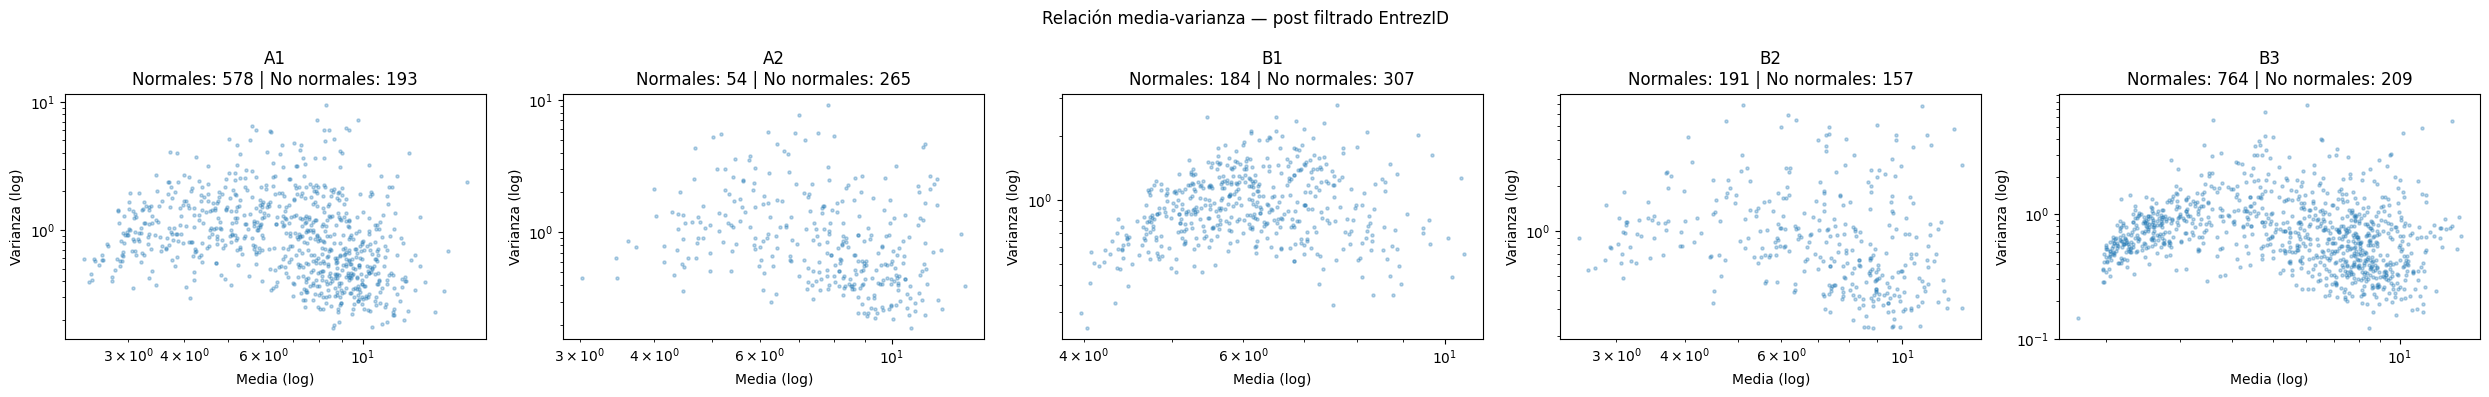

,Dataset,N° genes normales,N° genes no normales,% genes normales
0,A1,578,193,75.0
1,A2,54,265,16.9
2,B1,184,307,37.5
3,B2,191,157,54.9
4,B3,764,209,78.5


<timed exec>:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<timed exec>:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


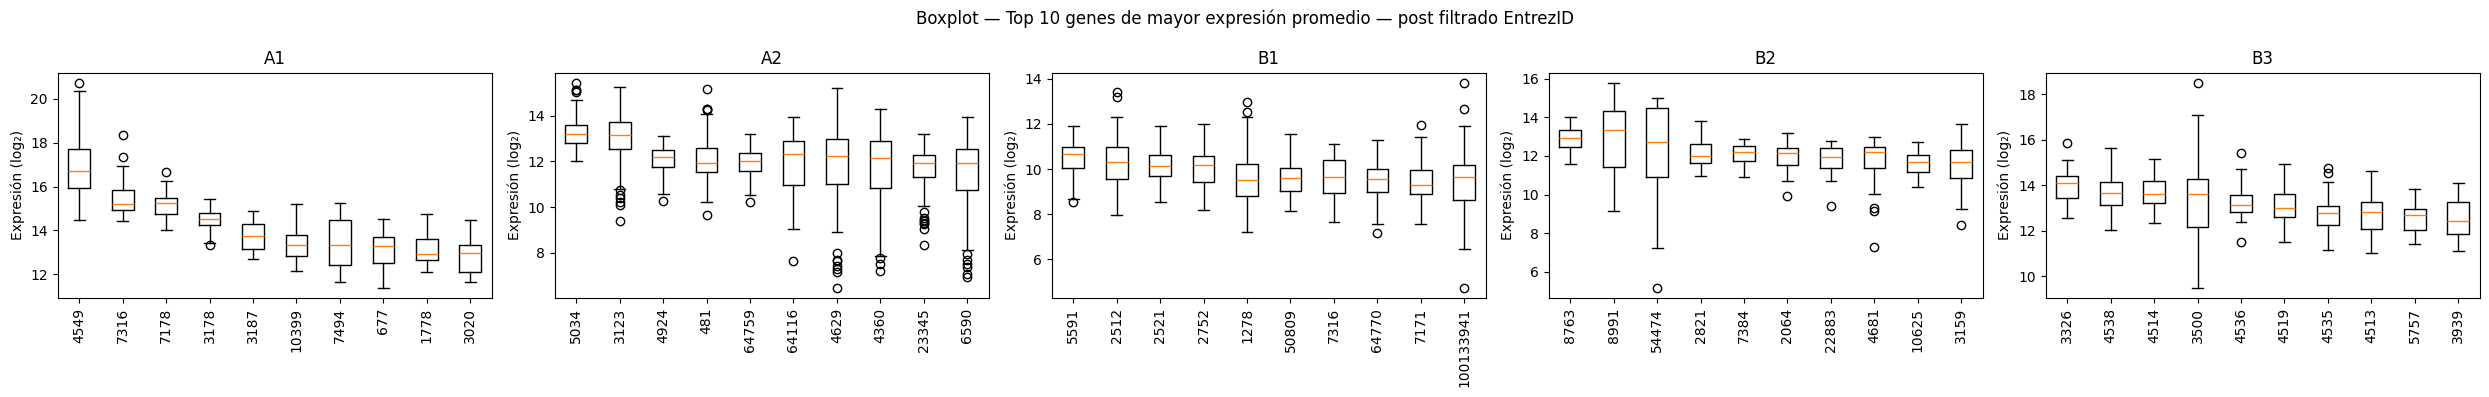

CPU times: total: 1.88 s
Wall time: 1.89 s


In [7]:
%%time
##############################
# Re-exploración post-filtrado (DATAFRAMES_FINAL)
##############################

# Paso 1 - Diagnóstico general
summary_rows_final = [processing_exploration(name, df) for name, df in DATAFRAMES_FINAL.items()]
summary_df_final = pd.DataFrame(summary_rows_final)
display(summary_df_final)

# Paso 2 y 3 - Relación media-varianza y conteo de normalidad (por gen).
n = len(DATAFRAMES_FINAL)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

normality_summary_rows_final = []
for ax, (name, df) in zip(axes, DATAFRAMES_FINAL.items()):
    result = processing_mean_variance(name, df, ax)
    normality_summary_rows_final.append(result)

fig.suptitle("Relación media-varianza — post filtrado EntrezID")
plt.tight_layout()
plt.show()

normality_summary_df_final = pd.DataFrame(normality_summary_rows_final)
display(normality_summary_df_final)

# Anexo: Boxplot de genes de mayor expresión — post filtrado EntrezID
N_TOP_GENES = 10  # cantidad de genes de mayor expresión promedio a graficar.

fig, axes = plt.subplots(1, len(DATAFRAMES_FINAL), figsize=(5 * len(DATAFRAMES_FINAL), 4))
if len(DATAFRAMES_FINAL) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, DATAFRAMES_FINAL.items()):
    cols_meta = ['ID', 'class']
    cols_gene = [c for c in df.columns if c not in cols_meta]
    df_genes  = df[cols_gene]

    # Genes ordenados por media de expresión (descendente) — top N.
    top_genes = df_genes.mean(axis=0).sort_values(ascending=False).head(N_TOP_GENES).index

    ax.boxplot(
        [df_genes[gen].dropna() for gen in top_genes],
        labels=top_genes,
        showfliers=True,
    )
    ax.set_title(f"{name}")
    ax.set_ylabel("Expresión (log₂)")
    ax.tick_params(axis='x', rotation=90)

fig.suptitle(f"Boxplot — Top {N_TOP_GENES} genes de mayor expresión promedio — post filtrado EntrezID")
plt.tight_layout()
plt.show()

In [8]:
############################
# Importaciones
############################
from biocluster.go.gene_similarity import compute_gene_similarity_matrix_by_batch, GeneSimilarityOptions  # Similitud semántica GO (Wang).
from biocluster.visualization.heatmaps import plot_clustered_heatmap, ClusteringOptions                   # Heatmaps con clustering jerárquico.

############################
# Constantes
############################
GENE_INFO_DIR = Path(os.getcwd()).resolve().parent / "Datasets" / "Bio_Info Resources" / "Homo_sapiens.gene_info"
OBO_DIR       = Path(os.getcwd()).resolve().parent / "Datasets" / "Bio_Info Resources" / "go.obo"
GAF_DIR       = Path(os.getcwd()).resolve().parent / "Datasets" / "Bio_Info Resources" / "HUMAN-uniprot.gaf"
MATRICES_DIR  = Path(os.getcwd()).resolve().parent / "Datasets" / "matrices"

############################
# Funciones secundarias
############################

def processing_expression_distance(dataX: np.ndarray, genes: np.ndarray) -> dict:
    """
    Calcula la matriz de distancia de expresión génica (M_DE) mediante
    correlación de Spearman entre genes, a partir de una matriz
    muestras x genes ya filtrada.

    Retorna tanto la matriz de distancia real (para uso en fórmulas, ej.
    Anexo 1: M_V = sqrt(M_DE² + M_DB²)) como la matriz de similitud
    normalizada en [0, 1] (compatible con plot_clustered_heatmap, que asume
    similitud y computa distancia internamente como 1 - similitud).
    """
    n_genes = dataX.shape[1]

    # Correlación de Spearman entre genes (columnas). axis=0: cada columna
    # es una variable (gen), las filas son observaciones (muestras).
    corr_matrix, pvalue_matrix = stats.spearmanr(dataX, axis=0)

    # Con exactamente 2 genes, spearmanr retorna un escalar en vez de matriz.
    if n_genes == 2:
        corr_matrix = np.array([[1.0, corr_matrix], [corr_matrix, 1.0]])
        pvalue_matrix = np.array([[0.0, pvalue_matrix], [pvalue_matrix, 0.0]])

    # Fuerza simetría exacta (por errores de precisión flotante) y diagonal = 1.
    corr_matrix = (corr_matrix + corr_matrix.T) / 2
    np.fill_diagonal(corr_matrix, 1.0)

    # Distancia real: 1 - correlación (rango [0, 2], convención estándar
    # en clustering de expresión génica).
    distance_matrix = 1.0 - corr_matrix

    # Similitud normalizada a [0, 1] para uso directo en plot_clustered_heatmap.
    similarity_matrix = (corr_matrix + 1.0) / 2.0

    n_nan = int(np.isnan(corr_matrix).sum())
    if n_nan > 0:
        print(f"Atención: {n_nan} pares de genes con correlación NaN "
              f"(probablemente por varianza cero en algún gen).")

    return {
        "genes":              genes,
        "corr_matrix":        corr_matrix,
        "pvalue_matrix":      pvalue_matrix,
        "distance_matrix":    distance_matrix,
        "similarity_matrix":  similarity_matrix,
        "n_genes":            n_genes,
    }

def processing_expression_distance_symbol(df_symbol: pd.DataFrame) -> dict:
    """
    Calcula la distancia de expresión (M_DE) directamente sobre un
    DataFrame con columnas ya renombradas a Symbol, para que el resultado
    quede en el mismo espacio de genes que la matriz de Wang.
    """
    cols_meta = ['ID', 'class']
    genes = np.array([c for c in df_symbol.columns if c not in cols_meta])
    dataX = df_symbol[genes].to_numpy()
    return processing_expression_distance(dataX, genes)

def processing_entrez_to_symbol(gene_list: list, path_gene_info: str, tax_id: int = 9606) -> tuple[pd.DataFrame, dict]:
    """
    Función que encapsula el reconocimiento de símbolos de gen (Symbol)
    asociados a una lista de EntrezID, a partir del archivo gene_info de NCBI.
    """
    cols = [
        "tax_id", "GeneID", "Symbol", "LocusTag", "Synonyms", "dbXrefs",
        "chromosome", "map_location", "description", "type_of_gene",
        "Symbol_from_nomenclature_authority", "Full_name_from_nomenclature_authority",
        "Nomenclature_status", "Other_designations", "Modification_date", "Feature_type"
    ]

    gene_info = pd.read_csv(
        path_gene_info,
        sep="\t",
        names=cols,
        header=0,          # el archivo trae su propia fila de encabezado
        na_values=["-"],
        dtype={"GeneID": "string", "Symbol": "string"},
        low_memory=False,
    )

    gene_info = gene_info[gene_info["tax_id"] == tax_id]

    # Un GeneID debería mapear a un único Symbol, pero se verifica igual.
    mapa_symbol = (
        gene_info.drop_duplicates(subset="GeneID")
        .set_index("GeneID")["Symbol"]
        .to_dict()
    )

    filas = []
    for entrez_id in gene_list:
        symbol = mapa_symbol.get(str(entrez_id))
        filas.append({
            "entrez_id": entrez_id,
            "symbol":    symbol,
            "estado":    "mapeado" if symbol is not None else "sin_mapeo",
        })

    mapping_df = pd.DataFrame(filas)

    # Symbols que resultan de más de un EntrezID (colisión potencial al renombrar).
    duplicados_df = (
        mapping_df.dropna(subset=["symbol"])
        .groupby("symbol")
        .filter(lambda g: len(g) > 1)
        .sort_values("symbol")
    )

    resumen = {
        "N° genes en lista original": len(gene_list),
        "N° genes mapeados":          int((mapping_df["estado"] == "mapeado").sum()),
        "N° genes sin mapeo":         int((mapping_df["estado"] == "sin_mapeo").sum()),
        "N° symbols duplicados":      mapping_df["entrez_id"].isin(duplicados_df["entrez_id"]).sum(),
        "% mapeado":                  round(100 * (mapping_df["estado"] == "mapeado").sum() / len(gene_list), 3) if gene_list else 0,
    }

    return mapping_df, duplicados_df, resumen

def preparar_symbols_para_wang(
    df: pd.DataFrame,
    mapping_df: pd.DataFrame,
    duplicados_df: pd.DataFrame,
    drop_sin_mapeo: bool = True
) -> tuple[pd.DataFrame, list[str]]:
    """
    Renombra las columnas EntrezID de un dataframe a su Symbol correspondiente,
    y retorna la lista de symbols lista para compute_gene_similarity_matrix_by_batch.
    Los EntrezID sin mapeo o con symbol duplicado se excluyen del renombrado
    (y de dataX si drop_sin_mapeo=True), en vez de resolverse silenciosamente.
    """
    ids_duplicados = set(duplicados_df["symbol"])

    renombrables = mapping_df[
        (mapping_df["estado"] == "mapeado") &
        (~mapping_df["symbol"].isin(ids_duplicados))
    ]
    mapa_rename = dict(zip(renombrables["entrez_id"].astype(str), renombrables["symbol"]))

    cols_meta = ['ID', 'class']
    genes_a_eliminar = [c for c in df.columns if c not in cols_meta and c not in mapa_rename]

    if drop_sin_mapeo:
        df_final = df.drop(columns=genes_a_eliminar)
    else:
        df_final = df.copy()

    df_final = df_final.rename(columns=mapa_rename)

    genes_symbol = [c for c in df_final.columns if c not in cols_meta]

    return df_final, genes_symbol

def compute_wang_average_multi_ontology(
    genes: list[str],
    obo_path: str,
    gaf_path: str,
    groupwise: str = "bma"
) -> dict:
    """
    Calcula la similitud de Wang para las 3 ontologías GO (BP, MF, CC) y
    retorna tanto las matrices individuales como su promedio elemento a
    elemento. Genes sin anotación en alguna ontología quedan como NaN en
    esa matriz específica; el promedio usa nanmean para no descartar el
    par por completo si al menos una ontología sí tiene el dato.
    """
    ontologias = ["BP", "MF", "CC"]
    matrices_por_ontologia = {}
    genes_ref = None

    for ont in ontologias:
        print(f"  Calculando similitud de Wang — ontología {ont}...")
        opts = GeneSimilarityOptions(ontology=ont, measure="wang", groupwise=groupwise)
        genes_list, sim_matrix = compute_gene_similarity_matrix_by_batch(
            genes, obo_path=obo_path, gaf_path=gaf_path, go3_opts=opts
        )

        if genes_ref is None:
            genes_ref = genes_list
        elif genes_list != genes_ref:
            raise ValueError(f"Orden de genes inconsistente entre ontologías (falló en {ont}).")

        matrices_por_ontologia[ont] = sim_matrix

    # Promedio elemento a elemento entre las 3 ontologías.
    stacked = np.stack([matrices_por_ontologia[o] for o in ontologias], axis=0)
    matriz_promedio = np.nanmean(stacked, axis=0)
    np.fill_diagonal(matriz_promedio, 1.0)

    n_nan = int(np.isnan(matriz_promedio).sum())
    if n_nan > 0:
        print(f"  Atención: {n_nan} pares de genes quedaron sin similitud en ninguna "
              f"de las 3 ontologías (NaN en el promedio final).")

    return {
        "genes":                  genes_ref,
        "matrices_por_ontologia": matrices_por_ontologia,
        "matriz_promedio":        matriz_promedio,
    }

def filter_genes_without_values(matrix: np.ndarray, genes: list[str], tol: float = 1e-9) -> dict:
    """
    Descarta de una matriz cuadrada y simétrica los genes cuya fila/columna
    esté completamente en (o prácticamente en) 0, excluyendo la diagonal.
    Usa una tolerancia en vez de igualdad estricta para evitar que residuos
    de punto flotante (ej. 1e-14 en vez de 0.0 exacto) impidan la detección.
    """
    n = matrix.shape[0]

    sin_diagonal = matrix.copy()
    np.fill_diagonal(sin_diagonal, 0)

    genes_validos = ~np.all(np.abs(sin_diagonal) <= tol, axis=1)

    genes_descartados = [g for g, valido in zip(genes, genes_validos) if not valido]
    genes_finales = [g for g, valido in zip(genes, genes_validos) if valido]
    matrix_final = matrix[np.ix_(genes_validos, genes_validos)]

    print(f"  Genes originales: {n}")
    print(f"  Genes descartados (sin valores, ≈0 con tol={tol}): {len(genes_descartados)}")
    print(f"  Genes finales: {len(genes_finales)}")

    return {"matrix_final": matrix_final, "genes_finales": genes_finales, "genes_descartados": genes_descartados}

def apply_gene_discard(matrix: np.ndarray, genes: list[str], genes_to_discard: list[str]) -> tuple[np.ndarray, list[str]]:
    """
    Descarta de una matriz cuadrada un conjunto de genes ya identificado
    externamente (ej. los descartados al filtrar la matriz de Wang),
    preservando el orden relativo de los genes restantes.
    """
    discard_set = set(genes_to_discard)
    mask = np.array([g not in discard_set for g in genes])

    genes_final = [g for g, m in zip(genes, mask) if m]
    matrix_final = matrix[np.ix_(mask, mask)]

    print(f"  Genes originales: {len(genes)}")
    print(f"  Genes descartados: {len(genes) - len(genes_final)}")
    print(f"  Genes finales: {len(genes_final)}")

    return matrix_final, genes_final

def guardar_matriz(matrix: np.ndarray, genes: list[str], nombre: str, tipo: str, out_dir: Path) -> Path:
    """
    Guarda una matriz cuadrada (genes como índice y columnas) en formato
    CSV dentro de out_dir, con nombre de archivo "{nombre}_{tipo}.csv"
    (ej. "A1_M_DE.csv", "A1_M_DB.csv").
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f"{nombre}_{tipo}.csv"
    pd.DataFrame(matrix, index=genes, columns=genes).to_csv(path)
    return path


Dataset : A1
  Symbols — {'N° genes en lista original': 771, 'N° genes mapeados': 771, 'N° genes sin mapeo': 0, 'N° symbols duplicados': np.int64(0), '% mapeado': np.float64(100.0)}
  Calculando similitud de Wang — ontología BP...
  Calculando similitud de Wang — ontología MF...
  Calculando similitud de Wang — ontología CC...
  Genes originales: 771
  Genes descartados (sin valores, ≈0 con tol=1e-09): 131
  Genes finales: 640
  Genes originales: 771
  Genes descartados: 131
  Genes finales: 640
  Matrices guardadas: A1_S_DE.csv, A1_S_DB.csv


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
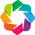

[clustered_heatmap_hv] Row clustering done (method=average, OLO=True).
[clustered_heatmap_hv] Column clustering done (method=average, OLO=True).


[clustered_heatmap_hv] HTML saved at: C:\Users\benja\Desktop\workspace\Thesis\Datasets\matrices\clustered_heatmap_GE_A1.html


[clustered_heatmap_hv] Row clustering done (method=average, OLO=True).
[clustered_heatmap_hv] Column clustering done (method=average, OLO=True).


[clustered_heatmap_hv] HTML saved at: C:\Users\benja\Desktop\workspace\Thesis\Datasets\matrices\clustered_heatmap_BI_A1.html

Dataset : A2
  Symbols — {'N° genes en lista original': 319, 'N° genes mapeados': 319, 'N° genes sin mapeo': 0, 'N° symbols duplicados': np.int64(0), '% mapeado': np.float64(100.0)}
  Calculando similitud de Wang — ontología BP...
  Calculando similitud de Wang — ontología MF...
  Calculando similitud de Wang — ontología CC...
  Genes originales: 319
  Genes descartados (sin valores, ≈0 con tol=1e-09): 31
  Genes finales: 288
  Genes originales: 319
  Genes descartados: 31
  Genes finales: 288
  Matrices guardadas: A2_S_DE.csv, A2_S_DB.csv


[clustered_heatmap_hv] Row clustering done (method=average, OLO=True).
[clustered_heatmap_hv] Column clustering done (method=average, OLO=True).


...

[clustered_heatmap_hv] HTML saved at: C:\Users\benja\Desktop\workspace\Thesis\Datasets\matrices\clustered_heatmap_GE_B3.html


[clustered_heatmap_hv] Row clustering done (method=average, OLO=True).
[clustered_heatmap_hv] Column clustering done (method=average, OLO=True).


[clustered_heatmap_hv] HTML saved at: C:\Users\benja\Desktop\workspace\Thesis\Datasets\matrices\clustered_heatmap_BI_B3.html

  RESUMEN — Matrices de similitud (S_DE y S_DB)


,Dataset,N° genes (Symbol),N° genes finales,Shape S_DE,Shape S_DB
0,A1,771,640,"(640, 640)","(640, 640)"
1,A2,319,288,"(288, 288)","(288, 288)"
2,B1,491,434,"(434, 434)","(434, 434)"
3,B2,348,316,"(316, 316)","(316, 316)"
4,B3,973,721,"(721, 721)","(721, 721)"



Matrices exportadas en: C:\Users\benja\Desktop\workspace\Thesis\Datasets\matrices
CPU times: total: 11min 11s
Wall time: 4min 25s


In [10]:
%%time
##############################
# EJECUCIÓN
##############################

DATAFRAMES_SYMBOL        = {}
GENES_SYMBOL_POR_DATASET = {}
RESULTADOS_WANG          = {}
RESULTADOS_EXPRESION     = {}
MATRICES_FINALES         = {}

for nombre, df in DATAFRAMES_FINAL.items():
    print(f"\n{'='*55}")
    print(f"Dataset : {nombre}")

    # Paso 1 - Reconocimiento de símbolos (EntrezID -> Symbol)
    cols_meta  = ['ID', 'class']
    entrez_ids = [c for c in df.columns if c not in cols_meta]

    mapping_df, duplicados_df, resumen = processing_entrez_to_symbol(entrez_ids, path_gene_info=str(GENE_INFO_DIR))
    print(f"  Symbols — {resumen}")

    if not duplicados_df.empty:
        print(f"  Atención — symbols duplicados en {nombre}:")
        display(duplicados_df)

    df_symbol, genes_symbol = preparar_symbols_para_wang(df, mapping_df, duplicados_df, drop_sin_mapeo=True)
    DATAFRAMES_SYMBOL[nombre]        = df_symbol
    GENES_SYMBOL_POR_DATASET[nombre] = genes_symbol

    # Paso 2 - Similitud biológica (Wang, promedio BP + MF + CC)
    resultado_wang = compute_wang_average_multi_ontology(
        genes_symbol, obo_path=str(OBO_DIR), gaf_path=str(GAF_DIR), groupwise="bma"
    )
    RESULTADOS_WANG[nombre] = resultado_wang

    # Paso 3 - Descarte de genes sin señal biológica (fila/columna ≈ 0 en Wang)
    resultado_filtrado = filter_genes_without_values(
        resultado_wang["matriz_promedio"], resultado_wang["genes"]
    )
    matriz_wang_final = resultado_filtrado["matrix_final"]
    genes_wang_final  = resultado_filtrado["genes_finales"]

    # Paso 4 - Similitud de expresión (Spearman) en el mismo espacio de símbolos
    resultado_expr = processing_expression_distance_symbol(df_symbol)
    matriz_expr_final, genes_expr_final = apply_gene_discard(
        resultado_expr["similarity_matrix"],
        list(resultado_expr["genes"]),
        resultado_filtrado["genes_descartados"]
    )
    RESULTADOS_EXPRESION[nombre] = resultado_expr

    # Verificación: ambos conjuntos de genes deben quedar idénticos
    assert genes_expr_final == genes_wang_final, \
        f"[{nombre}] Los genes finales de expresión y Wang no coinciden."

    MATRICES_FINALES[nombre] = {
        "genes":            genes_wang_final,
        "matriz_expresion": matriz_expr_final,
        "matriz_wang":      matriz_wang_final,
    }

    # Paso 5 - Guardado de matrices finales (carpeta "matrices")
    path_expr = guardar_matriz(matriz_expr_final, genes_wang_final, nombre, "S_DE", MATRICES_DIR)
    path_wang = guardar_matriz(matriz_wang_final, genes_wang_final, nombre, "S_DB", MATRICES_DIR)
    print(f"  Matrices guardadas: {path_expr.name}, {path_wang.name}")

    # Paso 6 - Heatmaps finales (guardados junto a las matrices, en "matrices")
    plot_clustered_heatmap(
        matrix=matriz_expr_final,
        labels=genes_wang_final,
        save_filepath=str(MATRICES_DIR / f"clustered_heatmap_GE_{nombre}.html"),
        title=f"Similitud de expresión (Spearman, filtrada) — {nombre}",
        z_label="Similitud de expresión",
        clustering=ClusteringOptions(linkage_method="average", optimal_leaf_order=True),
    )

    plot_clustered_heatmap(
        matrix=matriz_wang_final,
        labels=genes_wang_final,
        save_filepath=str(MATRICES_DIR / f"clustered_heatmap_BI_{nombre}.html"),
        title=f"Similitud biológica (Wang, promedio BP+MF+CC, filtrada) — {nombre}",
        z_label="Similitud Wang (promedio)",
        clustering=ClusteringOptions(linkage_method="average", optimal_leaf_order=True),
    )

# ============================================================
# RESUMEN FINAL — matrices de similitud por dataset
# ============================================================
separador = '=' * 55
print(f"\n{separador}")
print("  RESUMEN — Matrices de similitud (S_DE y S_DB)")
print(separador)

resumen_matrices_rows = []
for nombre, resultado in MATRICES_FINALES.items():
    resumen_matrices_rows.append({
        "Dataset":           nombre,
        "N° genes (Symbol)": len(GENES_SYMBOL_POR_DATASET[nombre]),
        "N° genes finales":  len(resultado["genes"]),
        "Shape S_DE":        resultado["matriz_expresion"].shape,
        "Shape S_DB":        resultado["matriz_wang"].shape,
    })

resumen_matrices_df = pd.DataFrame(resumen_matrices_rows)
display(resumen_matrices_df)

print(f"\nMatrices exportadas en: {MATRICES_DIR}")